# openpilot Vision Model 時系列推論分析

このノートブックでは、動画データから時系列で推論を実行し、モデル出力の時間的変化を分析します。

## 目的
- 動画から連続的に12フレームのシーケンスを抽出（スライディングウィンドウ）
- 各時点でVision Model推論を実行
- hidden_state、pose、desire_predなどの時系列変化を可視化
- 時間的一貫性を分析

## 処理フロー
1. 動画読み込みと基本情報取得
2. スライディングウィンドウで12フレームシーケンスを生成
3. 各シーケンスで推論実行
4. 時系列データの収集と整理
5. 時系列グラフの作成
6. アニメーション可視化

## 1. ライブラリのインポートと環境設定

### 目的
このセクションでは、ノートブック全体で使用するPythonライブラリをインポートし、作業に必要なパス設定を行います。

### インポートするライブラリ
- **numpy, cv2**: 画像処理と数値計算
- **matplotlib**: グラフ描画と可視化
- **pandas**: データ整理（時系列データのテーブル化）
- **tqdm**: プログレスバー表示（長時間処理の進捗確認）
- **onnxruntime**: ONNX形式のMLモデルの推論実行

### パス設定
- `OPENPILOT_ROOT`: openpilotのソースコードのルートディレクトリ
- `DATA_DIR`: comma3xで取得した動画データの保存場所
- `MODEL_DIR`: Vision/Policy Modelが格納されているディレクトリ

In [125]:
import os
import sys
import numpy as np
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from typing import Dict, List, Tuple
import pandas as pd
from tqdm import tqdm

# openpilotのルートディレクトリ
OPENPILOT_ROOT = Path("/home/takuya/work/comma/openpilot")
sys.path.insert(0, str(OPENPILOT_ROOT))

# データディレクトリ
DATA_DIR = Path("/media/takuya/Transcend/work/comma/data/20250719/00000015--d75e4db73c--4")

# モデルディレクトリ
MODEL_DIR = OPENPILOT_ROOT / "selfdrive" / "modeld" / "models"

print(f"✓ openpilot root: {OPENPILOT_ROOT}")
print(f"✓ Data directory: {DATA_DIR}")
print(f"✓ Data exists: {DATA_DIR.exists()}")
print(f"✓ Model directory: {MODEL_DIR}")
print(f"✓ Model directory exists: {MODEL_DIR.exists()}")

✓ openpilot root: /home/takuya/work/comma/openpilot
✓ Data directory: /media/takuya/Transcend/work/comma/data/20250719/00000015--d75e4db73c--4
✓ Data exists: True
✓ Model directory: /home/takuya/work/comma/openpilot/selfdrive/modeld/models
✓ Model directory exists: True


## 2. ONNX Runtimeのセットアップ

### 目的
ONNX形式のMLモデルを実行するために必要なライブラリを確認・インストールします。

### 処理内容
1. **onnxruntime**: ONNXモデルの推論エンジン
   - CPU上でモデルを実行
   - GPUがある場合は`onnxruntime-gpu`も利用可能
2. **onnx**: ONNXモデルの構造を読み取るためのライブラリ
   - モデルの入出力情報の確認に使用

### 確認事項
- インストール済みのバージョンを表示
- 未インストールの場合は自動的にpipでインストール

In [126]:
try:
    import onnxruntime as ort
    import onnx
    print(f"✓ ONNX Runtime version: {ort.__version__}")
    print(f"✓ ONNX version: {onnx.__version__}")
except ImportError:
    print("⚠ Installing ONNX Runtime and ONNX...")
    !pip install onnxruntime onnx
    import onnxruntime as ort
    import onnx

✓ ONNX Runtime version: 1.23.2
✓ ONNX version: 1.20.0


## 3. モデルの読み込み

### 目的
時系列分析に使用するVision Modelをメモリに読み込み、入出力仕様を確認します。

### 処理内容
1. **モデルファイルの確認**
   - `driving_vision.onnx`の存在確認
   - ファイルサイズの表示
   
2. **ONNXセッションの作成**
   - CPUで推論を実行するためのセッションを初期化
   - モデルの重みとアーキテクチャをメモリにロード

3. **入出力情報の表示**
   - **入力**: `input_imgs`, `big_input_imgs` (両方とも [1, 12, 128, 256])
   - **出力**: `outputs` ([1, 632]) - Vision Modelの予測結果

### なぜ2つの入力が必要？
openpilotのVision Modelは、標準解像度と高解像度の両方の画像を同時に処理する設計になっています。ここでは同じ画像を両方に渡します。

In [127]:
# Vision Modelのパス（時系列分析では標準モデルを使用）
MODEL_PATH = MODEL_DIR / "driving_vision.onnx"

if MODEL_PATH.exists():
    print(f"✓ Model found: {MODEL_PATH.name}")
    print(f"  Size: {MODEL_PATH.stat().st_size / (1024**2):.2f} MB")

    # ONNXセッションを作成
    session = ort.InferenceSession(str(MODEL_PATH), providers=["CPUExecutionProvider"])

    # 入出力情報を表示
    print("\n📋 Model I/O Information:")
    print("  Inputs:")
    for inp in session.get_inputs():
        print(f"    - {inp.name}: {inp.shape} ({inp.type})")
    print("  Outputs:")
    for out in session.get_outputs():
        print(f"    - {out.name}: {out.shape} ({out.type})")
else:
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

✓ Model found: driving_vision.onnx
  Size: 33.27 MB

📋 Model I/O Information:
  Inputs:
    - input_imgs: [1, 12, 128, 256] (tensor(uint8))
    - big_input_imgs: [1, 12, 128, 256] (tensor(uint8))
  Outputs:
    - outputs: [1, 632] (tensor(float16))


## 4. 動画の読み込みと基本情報取得

### 目的
時系列分析に使用する動画ファイルを特定し、基本的なメタデータを取得します。

### 処理内容
1. **動画ファイルの探索**
   - DATA_DIR内の`.ts`, `.hevc`, `.mp4`ファイルを検索
   - comma3xデータは通常`.ts`形式（MPEG-TS）で保存

2. **動画メタデータの取得**
   - **解像度**: 幅×高さ（ピクセル）
   - **FPS**: フレームレート（通常20fps）
   - **総フレーム数**: 動画全体のフレーム数
   - **再生時間**: 総フレーム数 ÷ FPS

### 重要性
これらの情報は後のフレーム抽出とタイムスタンプ計算に必要です。特にFPSは時系列データのタイムスタンプ生成に使用されます。

In [128]:
# 動画ファイルを探す
video_files = list(DATA_DIR.glob("*.ts")) + list(DATA_DIR.glob("*.hevc")) + list(DATA_DIR.glob("*.mp4"))

if not video_files:
    raise FileNotFoundError(f"No video files found in {DATA_DIR}")

video_path = video_files[0]
print(f"✓ Found video: {video_path.name}")

# 動画情報を取得
cap = cv2.VideoCapture(str(video_path))
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = total_frames / fps if fps > 0 else 0
cap.release()

print(f"\n📹 Video Information:")
print(f"  Resolution: {width}×{height}")
print(f"  FPS: {fps:.2f}")
print(f"  Total frames: {total_frames}")
print(f"  Duration: {duration:.2f} seconds")

✓ Found video: qcamera.ts

📹 Video Information:
  Resolution: 526×330
  FPS: 20.00
  Total frames: 1200
  Duration: 60.00 seconds


## 5. 前処理関数の定義

### 目的
動画フレームをVision Modelが受け入れる形式に変換する関数を定義します。

### preprocess_frames関数
openpilotのVision Modelは特定の前処理を必要とします：

1. **色空間変換**: RGB → YUV → Y（輝度）チャンネルのみ
   - グレースケール化（色情報を削除）
   - 計算量削減と一般化性能向上
   
2. **リサイズ**: 元の解像度 → 128×256ピクセル
   - モデルの入力サイズに合わせる
   - アスペクト比を維持しながら縮小
   
3. **データ型の保持**: uint8 (0-255)
   - 正規化は**行わない**（モデル内部で処理）
   - 整数型のまま保持することで精度を維持

4. **シーケンス化**: 12フレームをスタック
   - 時間軸を考慮した推論のため
   - 形状: (1, 12, 128, 256) = (バッチ, 時間, 高さ, 幅)

### parse_vision_output関数
632次元の出力を意味のある要素に分解：

- **meta** (0:55): 運転環境の予測（車線位置、道路幅など）
- **desire_pred** (55:87): 運転意図の確率分布（直進、左折、車線変更など）
- **pose** (87:99): 車両姿勢の推定（Roll/Pitch/Yaw, X/Y/Z位置）
- **wide_from_device_euler** (99:105): カメラの相対姿勢
- **road_transform** (105:117): 道路座標系への変換パラメータ
- **hidden_state** (117:629): 512次元の抽象特徴量（Policy Modelへの入力）
- **pad** (629:632): パディング

In [129]:
def preprocess_frames(frames: np.ndarray) -> np.ndarray:
    """
    openpilotモデル用にフレームを前処理

    Args:
        frames: (num_frames, H, W, 3) RGB画像

    Returns:
        processed: (1, num_frames, 128, 256) uint8画像 [0, 255]
    """
    num_frames = frames.shape[0]
    processed_frames = []

    for i in range(num_frames):
        frame = frames[i]

        # RGB → YUV変換（Yチャンネルのみ使用）
        yuv = cv2.cvtColor(frame, cv2.COLOR_RGB2YUV)
        y_channel = yuv[:, :, 0]

        # リサイズ (元サイズ → 128×256)
        resized = cv2.resize(y_channel, (256, 128), interpolation=cv2.INTER_LINEAR)

        processed_frames.append(resized)

    # (num_frames, 128, 256) → (1, num_frames, 128, 256)
    processed = np.stack(processed_frames, axis=0)[np.newaxis, ...]

    return processed.astype(np.uint8)


def parse_vision_output(output: np.ndarray) -> Dict[str, np.ndarray]:
    """
    Vision Modelの632次元出力を解析
    """
    assert output.shape[-1] == 632, f"Expected 632 dimensions, got {output.shape[-1]}"

    output_flat = output.flatten()

    parsed = {
        "meta": output_flat[0:55],
        "desire_pred": output_flat[55:87],
        "pose": output_flat[87:99],
        "wide_from_device_euler": output_flat[99:105],
        "road_transform": output_flat[105:117],
        "hidden_state": output_flat[117:629],
        "pad": output_flat[629:632],
    }

    return parsed

print("✓ Preprocessing functions defined")

✓ Preprocessing functions defined


## 6. スライディングウィンドウでフレームシーケンスを抽出

### 目的
時系列分析のためのパラメータを設定します。動画全体から定期的にフレームシーケンスをサンプリングする方法を決定します。

### パラメータの意味

1. **SEQUENCE_LENGTH = 12**
   - 1回の推論に使用するフレーム数
   - Vision Modelは12フレームの履歴を見て予測
   - 約0.6秒分の映像（20fps × 12 ≈ 0.6秒）

2. **STRIDE = 6**
   - ウィンドウをスライドさせる間隔（フレーム数）
   - 6フレームごとに新しい推論を実行
   - オーバーラップ: 12 - 6 = 6フレーム（50%のオーバーラップ）

3. **START_FRAME = 100**
   - 分析開始位置
   - 最初の数秒をスキップすることで安定した走行シーンから開始

4. **NUM_SEQUENCES = 50**
   - 実行する推論の回数
   - 50回の推論 → 50個の時系列データポイント
   - カバーする時間: (50-1) × 6 / 20fps ≈ 14.7秒

### スライディングウィンドウの動作イメージ
```
時刻:  [100-111] [106-117] [112-123] [118-129] ...
         ↓         ↓         ↓         ↓
       推論1     推論2     推論3     推論4
```

### なぜオーバーラップが必要？
- 滑らかな時系列データを得るため
- 急激な変化を見逃さないため
- フレーム間の連続性を保つため

In [130]:
# 時系列分析のパラメータ
SEQUENCE_LENGTH = 12  # 各推論に使用するフレーム数
STRIDE = 6            # スライディングウィンドウのストライド（6フレームごとに推論）
START_FRAME = 100     # 開始フレーム
NUM_SEQUENCES = 50    # 処理するシーケンス数

print(f"⚙️ Time-Series Parameters:")
print(f"  Sequence length: {SEQUENCE_LENGTH} frames")
print(f"  Stride: {STRIDE} frames")
print(f"  Start frame: {START_FRAME}")
print(f"  Number of sequences: {NUM_SEQUENCES}")
print(f"  Total frames needed: {START_FRAME + SEQUENCE_LENGTH + (NUM_SEQUENCES-1) * STRIDE}")

⚙️ Time-Series Parameters:
  Sequence length: 12 frames
  Stride: 6 frames
  Start frame: 100
  Number of sequences: 50
  Total frames needed: 406


## 7. 時系列推論の実行

### 目的
動画からフレームを抽出し、Vision Modelで推論を実行して、時系列データを収集します。

### 処理フロー

1. **フレームシーケンス抽出** (`extract_frame_sequence`)
   - 指定位置から連続12フレームを読み込み
   - BGR（OpenCV形式）→ RGB変換
   - NumPy配列として返却

2. **前処理**
   - RGBフレーム → YUVのYチャンネル
   - 128×256にリサイズ
   - uint8形式で保持

3. **推論実行**
   - 2つの入力（`input_imgs`, `big_input_imgs`）に同じデータを渡す
   - ONNXセッションで推論
   - 出力: 632次元ベクトル

4. **出力解析**
   - `parse_vision_output`で構造化されたデータに変換
   - meta, desire_pred, pose, hidden_stateなど

5. **結果保存**
   各シーケンスについて以下を保存：
   - `sequence_idx`: シーケンス番号（0, 1, 2, ...）
   - `frame_idx`: 動画内のフレーム番号
   - `timestamp`: 秒単位の時刻（frame_idx / fps）
   - `parsed`: 解析済み出力
   - `raw_output`: 生の632次元ベクトル

### 進捗表示
`tqdm`によるプログレスバーで推論の進行状況を可視化します。50回の推論は数分かかる場合があります。

### エラーハンドリング
フレーム読み込みや推論に失敗した場合は、エラーメッセージを表示してループを終了します。

In [131]:
def extract_frame_sequence(video_path: Path, start_frame: int, num_frames: int = 12) -> np.ndarray:
    """連続フレームを抽出"""
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    frames = []
    for i in range(num_frames):
        ret, frame = cap.read()
        if not ret:
            break
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)

    cap.release()

    if len(frames) < num_frames:
        raise RuntimeError(f"Only got {len(frames)}/{num_frames} frames")

    return np.array(frames)


# 時系列推論の実行
time_series_results = []

print("🔄 Running time-series inference...")
for seq_idx in tqdm(range(NUM_SEQUENCES)):
    frame_idx = START_FRAME + seq_idx * STRIDE

    try:
        # フレームシーケンスを抽出
        frames = extract_frame_sequence(video_path, frame_idx, SEQUENCE_LENGTH)

        # 前処理
        input_tensor = preprocess_frames(frames)

        # 推論実行
        inputs = {
            "input_imgs": input_tensor,
            "big_input_imgs": input_tensor,
        }

        output_names = [out.name for out in session.get_outputs()]
        outputs = session.run(output_names, inputs)

        # 出力を解析
        vision_output = outputs[0]
        parsed = parse_vision_output(vision_output)

        # 結果を保存
        result = {
            "sequence_idx": seq_idx,
            "frame_idx": frame_idx,
            "timestamp": frame_idx / fps if fps > 0 else 0,
            "parsed": parsed,
            "raw_output": vision_output,
        }
        time_series_results.append(result)

    except Exception as e:
        print(f"\n⚠ Error at sequence {seq_idx} (frame {frame_idx}): {e}")
        break

print(f"\n✓ Completed {len(time_series_results)} inferences")

🔄 Running time-series inference...


100%|████████████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 26.75it/s]


✓ Completed 50 inferences


## 8. 時系列データの整理

### 目的
推論結果をNumPy配列に変換して、時系列分析とグラフ描画を容易にします。

### データ変換の内容

1. **タイムスタンプ配列**
   - 各シーケンスの時刻（秒）を抽出
   - グラフのX軸として使用

2. **フレームインデックス配列**
   - 各シーケンスの動画内フレーム番号
   - 元動画との対応付けに使用

3. **出力要素の配列化**
   - **hidden_states** (N, 512): 512次元の特徴量を時系列で並べる
   - **poses** (N, 12): 姿勢パラメータの時系列
   - **desire_preds** (N, 32): 運転意図の時系列
   - **metas** (N, 55): 運転環境の時系列

   ここでNは推論回数（NUM_SEQUENCES）

### なぜ配列化が必要？
- リスト形式では効率的な数値計算ができない
- NumPy配列に変換することで：
  - スライシング操作が高速
  - 統計計算（平均、標準偏差など）が容易
  - matplotlibでの描画が効率的
  - 行列演算が可能

### データの確認
各配列の形状（shape）を表示して、正しく変換されたことを確認します。

In [132]:
# 時系列データを整理
timestamps = [r["timestamp"] for r in time_series_results]
frame_indices = [r["frame_idx"] for r in time_series_results]

# 各出力要素の時系列データを抽出
hidden_states = np.array([r["parsed"]["hidden_state"] for r in time_series_results])  # (N, 512)
poses = np.array([r["parsed"]["pose"] for r in time_series_results])  # (N, 12)
desire_preds = np.array([r["parsed"]["desire_pred"] for r in time_series_results])  # (N, 32)
metas = np.array([r["parsed"]["meta"] for r in time_series_results])  # (N, 55)

print(f"📊 Time-Series Data Shape:")
print(f"  Timestamps: {len(timestamps)} points")
print(f"  Hidden states: {hidden_states.shape}")
print(f"  Poses: {poses.shape}")
print(f"  Desire predictions: {desire_preds.shape}")
print(f"  Meta: {metas.shape}")

📊 Time-Series Data Shape:
  Timestamps: 50 points
  Hidden states: (50, 512)
  Poses: (50, 12)
  Desire predictions: (50, 32)
  Meta: (50, 55)


## 9. 時系列可視化 (1) - Poseの時間変化

### 目的
車両の姿勢（Pose）が時間とともにどのように変化するかを可視化します。

### Poseの構造
12次元 = 6変数 × 2パラメータ（平均μ, 標準偏差σ）

**6変数の意味**：
1. **Roll**: 車体の傾き（左右方向）- 単位: ラジアン
2. **Pitch**: 車体の傾き（前後方向）- 上り坂/下り坂
3. **Yaw**: 車体の向き（水平回転）- 方向転換
4. **X**: 横方向の位置
5. **Y**: 前後方向の位置
6. **Z**: 高さ方向の位置

### 可視化の内容
各変数について：
- **青線**: 平均値（μ）の時系列
- **青い影**: ±1σ（標準偏差）の範囲
  - 予測の不確実性を表す
  - 影が広い = 予測の信頼度が低い
  - 影が狭い = 予測の信頼度が高い

### 解釈のヒント
- **Roll/Pitch**: 路面の傾斜や車両の動きを反映
- **Yaw**: カーブや方向転換で大きく変化
- **X/Y/Z**: 車両の3次元位置の推定値
- 値が滑らかに変化 = 安定した予測
- 値が急激に変化 = シーン変化やイベント発生

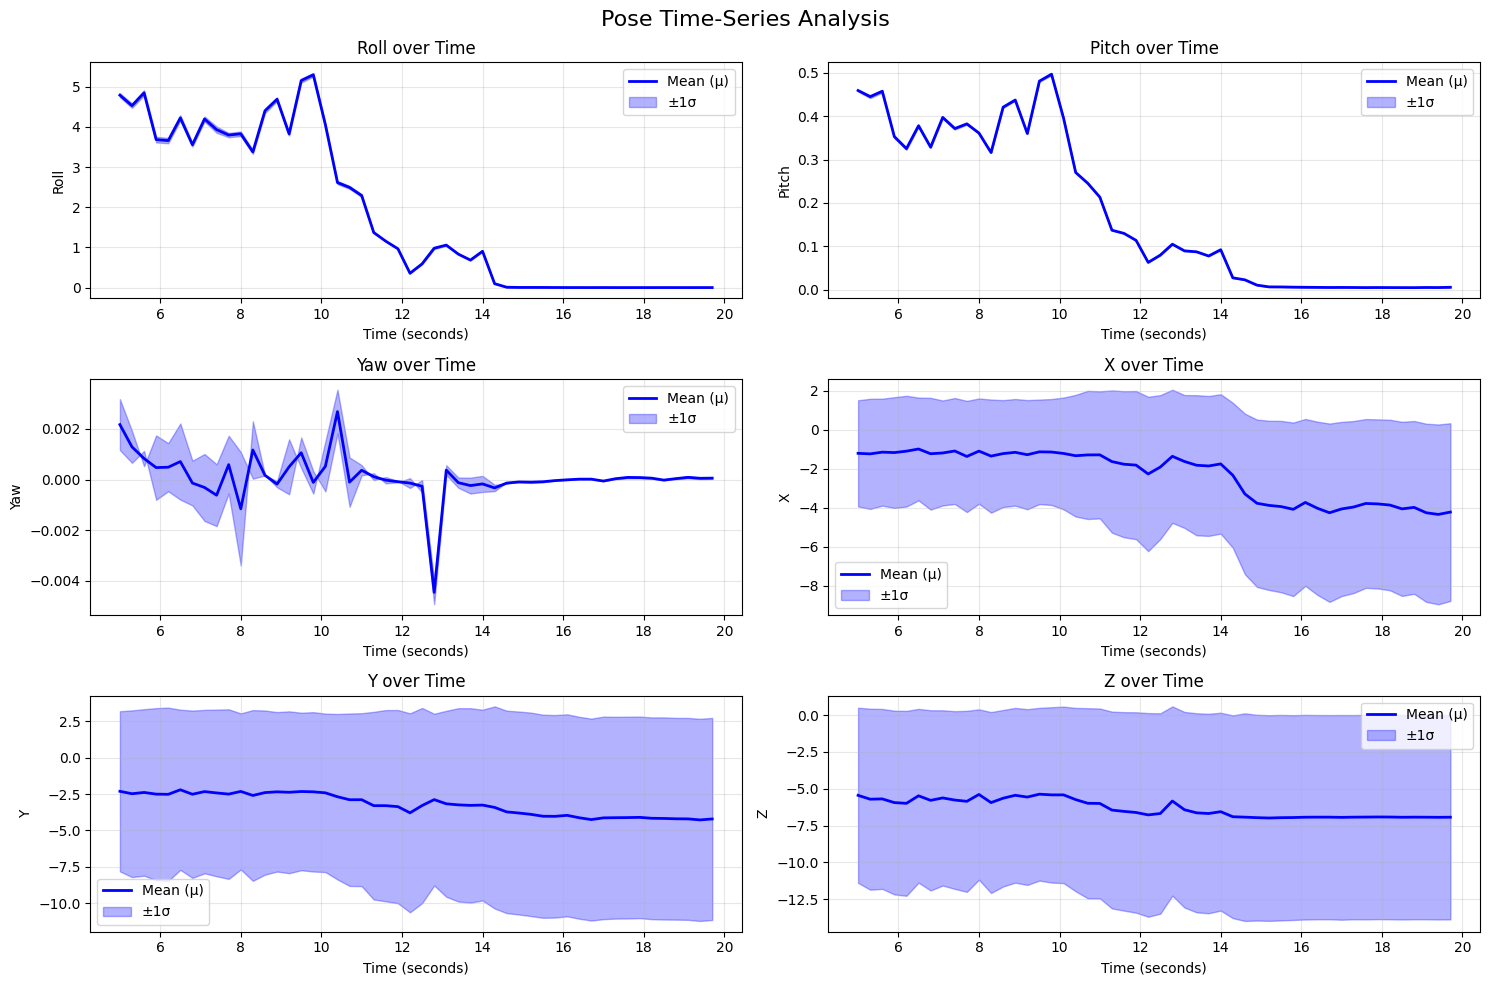

In [133]:
# Pose (12次元) = 6変数 × (μ, σ)
# 変数: Roll, Pitch, Yaw, X, Y, Z
pose_names = ['Roll', 'Pitch', 'Yaw', 'X', 'Y', 'Z']
pose_means = poses[:, ::2]  # 偶数インデックス = 平均
pose_stds = poses[:, 1::2]  # 奇数インデックス = 標準偏差

fig, axes = plt.subplots(3, 2, figsize=(15, 10))
fig.suptitle('Pose Time-Series Analysis', fontsize=16)

for i, (ax, name) in enumerate(zip(axes.flatten(), pose_names)):
    # 平均値をプロット
    ax.plot(timestamps, pose_means[:, i], 'b-', label='Mean (μ)', linewidth=2)

    # 標準偏差を影として表示
    ax.fill_between(timestamps,
                     pose_means[:, i] - pose_stds[:, i],
                     pose_means[:, i] + pose_stds[:, i],
                     alpha=0.3, color='blue', label='±1σ')

    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel(f'{name}')
    ax.set_title(f'{name} over Time')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## 10. 時系列可視化 (2) - Hidden Stateの進化

### 目的
512次元のHidden State（抽象特徴量）がどのように時間発展するかを多角的に分析します。

### Hidden Stateとは？
Vision Modelの内部表現で、以下の情報を圧縮して保持：
- 道路の形状
- 周囲の車両
- 車線マーカー
- 運転状況全般

Policy Modelへの入力として使用され、実際の制御出力（ハンドル角度など）を生成します。

### 4つの可視化

1. **ヒートマップ（時間 × 次元）**
   - 縦軸: 512次元
   - 横軸: 時間
   - 色: 値の大きさ
   - パターンを見ることで、どの次元が活発に変化しているかわかる

2. **特定次元の時系列（最初の10次元）**
   - 個別の次元がどう変化するか
   - 異なる色で区別
   - 相関関係の確認

3. **統計量の時系列**
   - 全512次元の平均値と標準偏差
   - 全体的な活性化レベルの変化
   - 影（±1σ）で値のばらつきを表示

4. **分布の変化**
   - 開始時点、中間、終了時点の3つを比較
   - ヒストグラムで値の分布を表示
   - 分布の形状変化からシーン変化を検出

### 解釈のポイント
- 値が突然変化 = 新しい情報の入力（カーブ、車両検出など）
- 周期的な変化 = 繰り返しパターン（車線マーカーなど）
- 一定の値 = 変化の少ない環境（直線道路など）

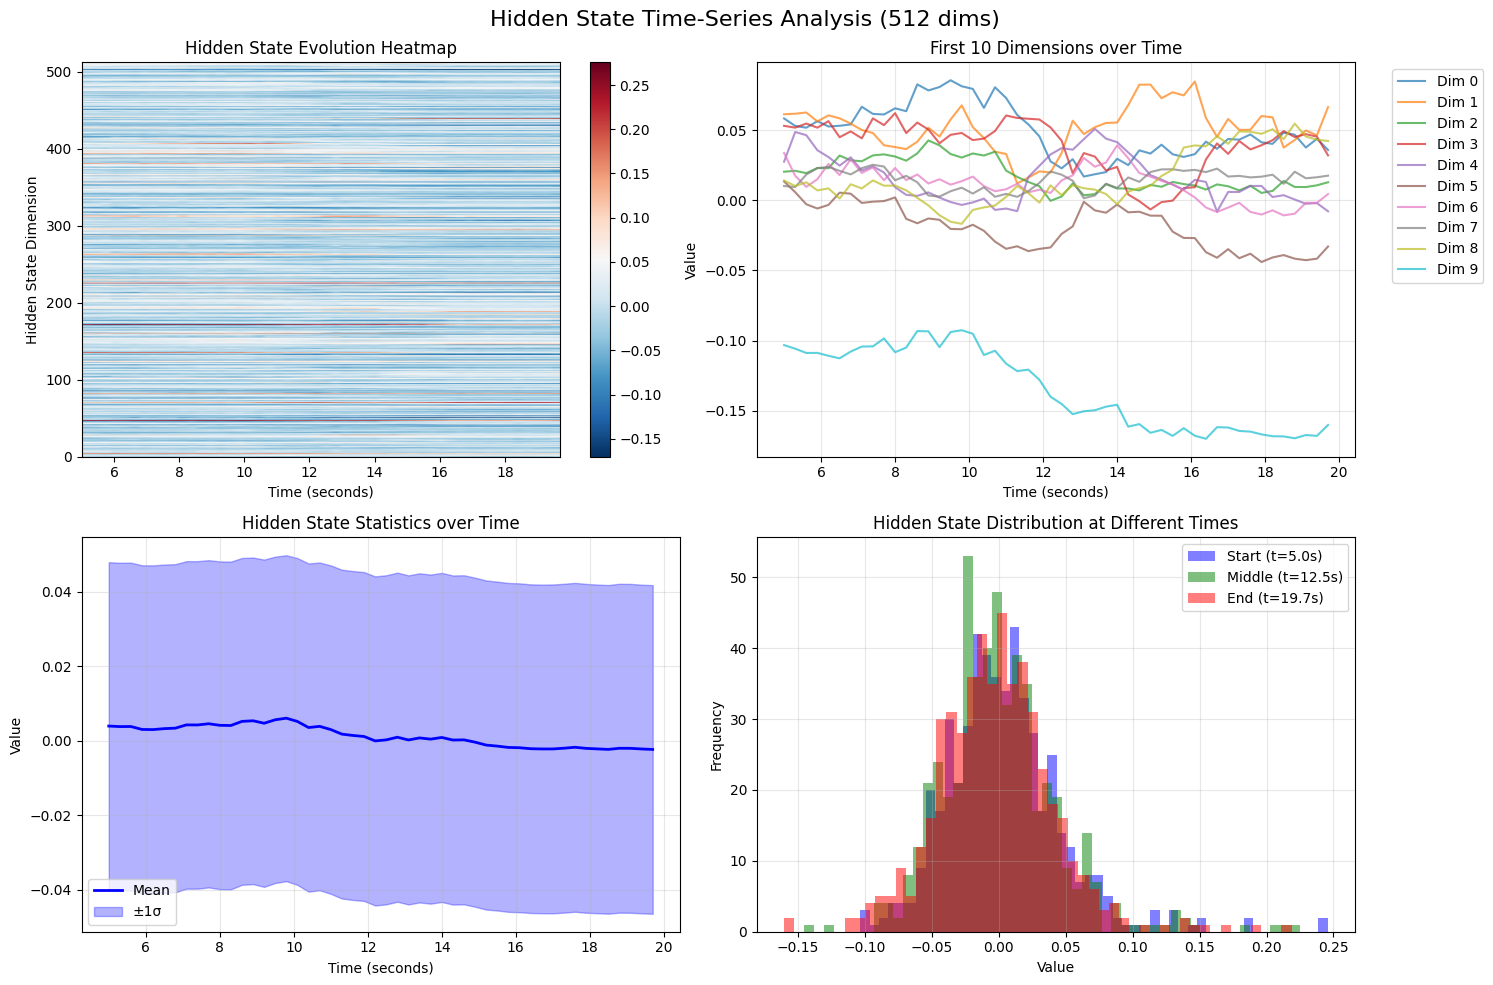

In [134]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Hidden State Time-Series Analysis (512 dims)', fontsize=16)

# 1. ヒートマップ（時間 × 次元）
im = axes[0, 0].imshow(hidden_states.T, aspect='auto', cmap='RdBu_r',
                       extent=[timestamps[0], timestamps[-1], 0, 512])
axes[0, 0].set_xlabel('Time (seconds)')
axes[0, 0].set_ylabel('Hidden State Dimension')
axes[0, 0].set_title('Hidden State Evolution Heatmap')
plt.colorbar(im, ax=axes[0, 0])

# 2. 特定の次元の時系列（最初の10次元）
for dim in range(10):
    axes[0, 1].plot(timestamps, hidden_states[:, dim], alpha=0.7, label=f'Dim {dim}')
axes[0, 1].set_xlabel('Time (seconds)')
axes[0, 1].set_ylabel('Value')
axes[0, 1].set_title('First 10 Dimensions over Time')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 3. 統計量の時系列（平均・標準偏差）
hidden_means = hidden_states.mean(axis=1)
hidden_stds = hidden_states.std(axis=1)
axes[1, 0].plot(timestamps, hidden_means, 'b-', label='Mean', linewidth=2)
axes[1, 0].fill_between(timestamps,
                        hidden_means - hidden_stds,
                        hidden_means + hidden_stds,
                        alpha=0.3, color='blue', label='±1σ')
axes[1, 0].set_xlabel('Time (seconds)')
axes[1, 0].set_ylabel('Value')
axes[1, 0].set_title('Hidden State Statistics over Time')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 4. 分布の変化（最初・中間・最後）
indices = [0, len(hidden_states)//2, len(hidden_states)-1]
colors = ['blue', 'green', 'red']
labels = ['Start', 'Middle', 'End']
for idx, color, label in zip(indices, colors, labels):
    axes[1, 1].hist(hidden_states[idx], bins=50, alpha=0.5, color=color,
                   label=f'{label} (t={timestamps[idx]:.1f}s)')
axes[1, 1].set_xlabel('Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Hidden State Distribution at Different Times')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. 時系列可視化 (3) - Desire Prediction

### 目的
運転意図（Desire）の予測がどのように時間変化するかを分析します。

### Desire Predictionとは？
運転者が次にどのような行動を取るかの確率分布：

**8つのカテゴリ**：
1. **none**: 特定の意図なし（通常走行）
2. **turn_left**: 左折
3. **turn_right**: 右折
4. **lane_change_left**: 左への車線変更
5. **lane_change_right**: 右への車線変更
6. **keep_left**: 左寄り走行を維持
7. **keep_right**: 右寄り走行を維持
8. **other**: その他

### 4次元の時間軸
32次元 = 4タイムステップ × 8カテゴリ

- t=0: 現在
- t=1, 2, 3: 未来の予測（短期、中期、長期）

### 4つの可視化

1. **各カテゴリの確率時系列（t=0）**
   - 8本の線が各カテゴリの確率
   - どのカテゴリが優勢かが一目瞭然
   - 線が上昇 = その意図が強まる

2. **ヒートマップ**
   - 時間 × カテゴリの2次元表示
   - 明るい部分 = 確率が高い
   - パターンの変化を視覚的に把握

3. **最も可能性の高いカテゴリ**
   - 各時点で最大確率のカテゴリを表示
   - カテゴリの切り替わりを明確に表示
   - 運転行動の遷移を追跡

4. **予測の確信度**
   - 最大確率の値（0-1）
   - 高い値 = 強い確信
   - 低い値 = 不確実な状況

### 実用的な解釈
- noneが高い = 通常走行
- lane_changeが高まる = 車線変更の意図を検出
- 確信度の低下 = 複雑な状況（交差点など）

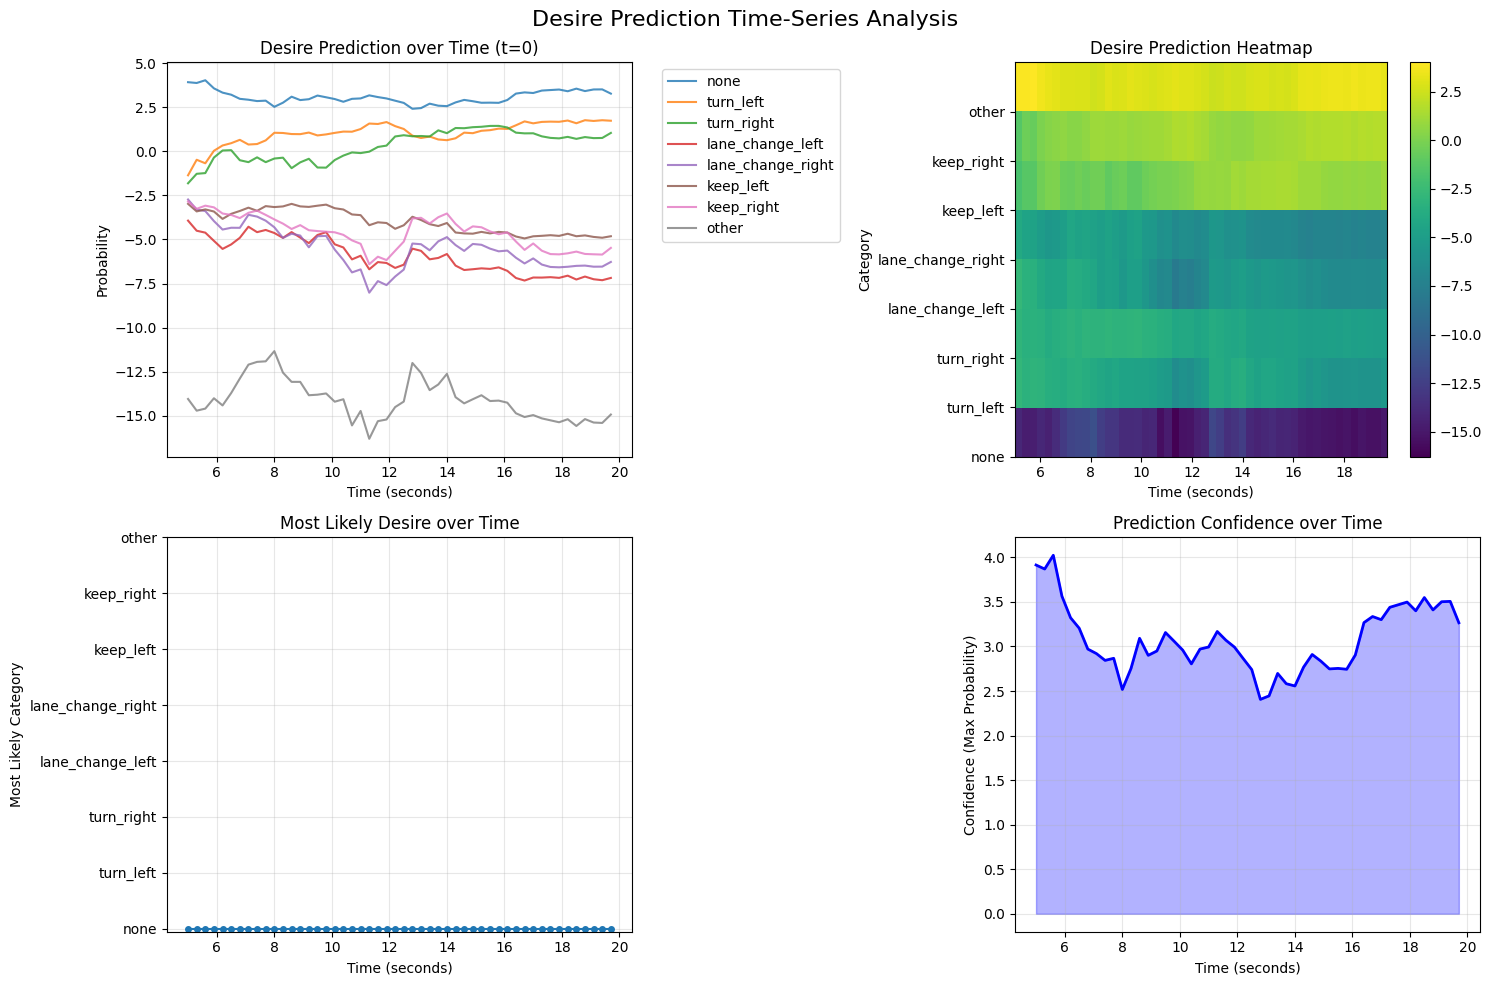

In [135]:
# Desire Prediction (32次元) = 4タイムステップ × 8カテゴリ
desire_reshaped = desire_preds.reshape(-1, 4, 8)  # (N, 4, 8)

# カテゴリ名（openpilot標準）
desire_categories = ['none', 'turn_left', 'turn_right', 'lane_change_left',
                     'lane_change_right', 'keep_left', 'keep_right', 'other']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Desire Prediction Time-Series Analysis', fontsize=16)

# 1. 各カテゴリの確率の時系列（タイムステップ0のみ）
for cat_idx, cat_name in enumerate(desire_categories):
    axes[0, 0].plot(timestamps, desire_reshaped[:, 0, cat_idx],
                   label=cat_name, alpha=0.8)
axes[0, 0].set_xlabel('Time (seconds)')
axes[0, 0].set_ylabel('Probability')
axes[0, 0].set_title('Desire Prediction over Time (t=0)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 2. ヒートマップ（時間 × カテゴリ、タイムステップ0）
im = axes[0, 1].imshow(desire_reshaped[:, 0, :].T, aspect='auto', cmap='viridis',
                      extent=[timestamps[0], timestamps[-1], 0, 8])
axes[0, 1].set_xlabel('Time (seconds)')
axes[0, 1].set_ylabel('Category')
axes[0, 1].set_yticks(range(8))
axes[0, 1].set_yticklabels(desire_categories)
axes[0, 1].set_title('Desire Prediction Heatmap')
plt.colorbar(im, ax=axes[0, 1])

# 3. 最も可能性の高いカテゴリの推移
most_likely = desire_reshaped[:, 0, :].argmax(axis=1)
axes[1, 0].plot(timestamps, most_likely, 'o-', markersize=4)
axes[1, 0].set_xlabel('Time (seconds)')
axes[1, 0].set_ylabel('Most Likely Category')
axes[1, 0].set_yticks(range(8))
axes[1, 0].set_yticklabels(desire_categories)
axes[1, 0].set_title('Most Likely Desire over Time')
axes[1, 0].grid(True, alpha=0.3)

# 4. 確信度（最大確率）の時系列
confidence = desire_reshaped[:, 0, :].max(axis=1)
axes[1, 1].plot(timestamps, confidence, 'b-', linewidth=2)
axes[1, 1].fill_between(timestamps, 0, confidence, alpha=0.3, color='blue')
axes[1, 1].set_xlabel('Time (seconds)')
axes[1, 1].set_ylabel('Confidence (Max Probability)')
axes[1, 1].set_title('Prediction Confidence over Time')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. 時間的一貫性の分析

### 目的
連続するフレーム間でモデルの出力がどれだけ変化するかを定量化し、予測の安定性を評価します。

### なぜ一貫性が重要？
- **安全性**: 急激な予測変化は制御の不安定性につながる
- **信頼性**: 滑らかな変化は予測の信頼性が高い
- **異常検出**: 急激な変化は異常イベントの可能性

### 3つの指標

1. **Hidden State変化量（L2ノルム）**
   - 計算: ||h(t) - h(t-1)||₂（ユークリッド距離）
   - 512次元全体の変化量
   - 大きな値 = シーンの大きな変化

2. **Pose変化量（絶対値の和）**
   - 計算: Σ|pose(t) - pose(t-1)|
   - 車両姿勢の変化量
   - 急激な変化 = 急な動き（加速、ブレーキ、ハンドル操作）

3. **Desire Prediction変化量**
   - 計算: Σ|desire(t) - desire(t-1)|
   - 運転意図の変化量
   - 大きな変化 = 行動の切り替わり

### グラフの見方
- **青線**: 実際の変化量
- **赤破線**: 平均値（ベースライン）
- **青い影**: 変化量の累積（面積）

### 統計サマリ
各指標について：
- **Mean**: 平均的な変化量（通常の変動レベル）
- **Std**: 変化量のばらつき
- **Max**: 最大変化量（最も大きなイベント）
- **Min**: 最小変化量（最も安定した区間）

### 解釈
- 平均的な変化量が小さい = 安定した予測
- 標準偏差が小さい = 一貫した変化パターン
- 突出したピーク = 特定のイベント（車線変更、障害物など）

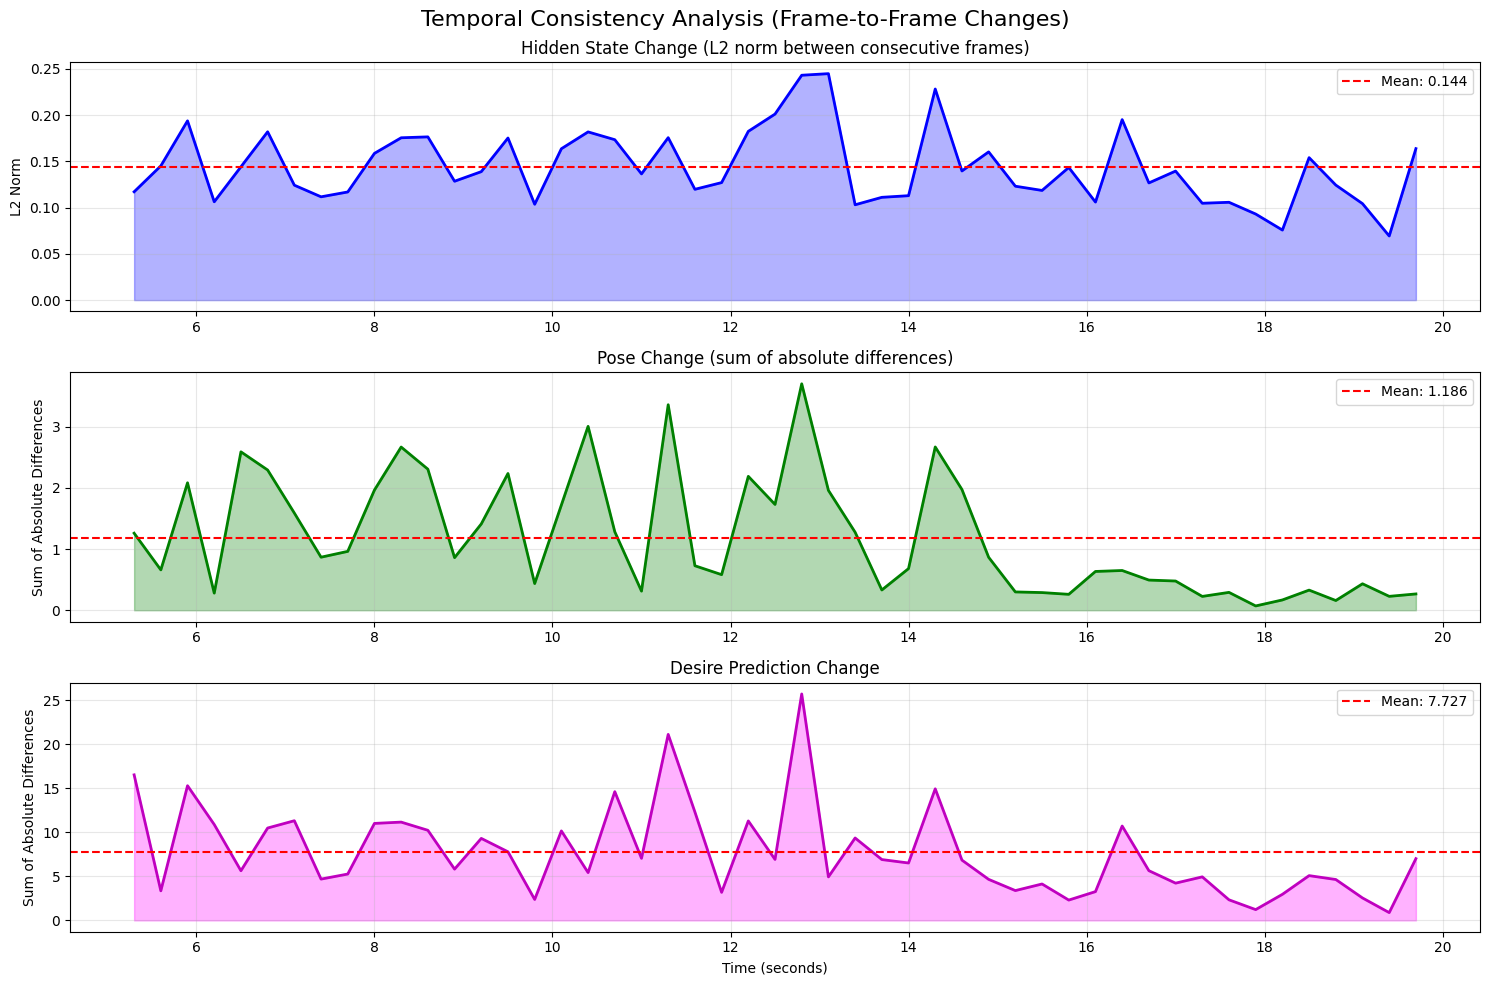


📊 Temporal Consistency Statistics:

Hidden State Changes:
  Mean: 0.1439
  Std:  0.0398
  Max:  0.2449
  Min:  0.0693

Pose Changes:
  Mean: 1.1855
  Std:  0.9604
  Max:  3.6992
  Min:  0.0706


In [136]:
# 時間的一貫性の分析：連続フレーム間の変化量

# Hidden stateの変化量（L2ノルム）
hidden_state_diffs = np.linalg.norm(np.diff(hidden_states, axis=0), axis=1)

# Poseの変化量（各要素の絶対値の合計）
pose_diffs = np.abs(np.diff(poses, axis=0)).sum(axis=1)

# Desire predictionの変化量
desire_diffs = np.abs(np.diff(desire_preds, axis=0)).sum(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(15, 10))
fig.suptitle('Temporal Consistency Analysis (Frame-to-Frame Changes)', fontsize=16)

# 1. Hidden state変化量
axes[0].plot(timestamps[1:], hidden_state_diffs, 'b-', linewidth=2)
axes[0].axhline(y=hidden_state_diffs.mean(), color='r', linestyle='--',
               label=f'Mean: {hidden_state_diffs.mean():.3f}')
axes[0].fill_between(timestamps[1:], 0, hidden_state_diffs, alpha=0.3, color='blue')
axes[0].set_ylabel('L2 Norm')
axes[0].set_title('Hidden State Change (L2 norm between consecutive frames)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 2. Pose変化量
axes[1].plot(timestamps[1:], pose_diffs, 'g-', linewidth=2)
axes[1].axhline(y=pose_diffs.mean(), color='r', linestyle='--',
               label=f'Mean: {pose_diffs.mean():.3f}')
axes[1].fill_between(timestamps[1:], 0, pose_diffs, alpha=0.3, color='green')
axes[1].set_ylabel('Sum of Absolute Differences')
axes[1].set_title('Pose Change (sum of absolute differences)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# 3. Desire prediction変化量
axes[2].plot(timestamps[1:], desire_diffs, 'm-', linewidth=2)
axes[2].axhline(y=desire_diffs.mean(), color='r', linestyle='--',
               label=f'Mean: {desire_diffs.mean():.3f}')
axes[2].fill_between(timestamps[1:], 0, desire_diffs, alpha=0.3, color='magenta')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Sum of Absolute Differences')
axes[2].set_title('Desire Prediction Change')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

# 統計サマリ
print("\n📊 Temporal Consistency Statistics:")
print(f"\nHidden State Changes:")
print(f"  Mean: {hidden_state_diffs.mean():.4f}")
print(f"  Std:  {hidden_state_diffs.std():.4f}")
print(f"  Max:  {hidden_state_diffs.max():.4f}")
print(f"  Min:  {hidden_state_diffs.min():.4f}")

print(f"\nPose Changes:")
print(f"  Mean: {pose_diffs.mean():.4f}")
print(f"  Std:  {pose_diffs.std():.4f}")
print(f"  Max:  {pose_diffs.max():.4f}")
print(f"  Min:  {pose_diffs.min():.4f}")

## 13. 動画とPoseの統合可視化（サンプル）

### 目的
実際の動画フレームとモデルのPose予測を並べて表示し、視覚的に対応関係を確認します。

### 表示内容
5つのサンプル時点を選択（開始、1/4、中間、3/4、終了）：

**左側**: 元の動画フレーム
- 実際のカメラ映像
- RGB画像そのまま
- フレーム番号と時刻を表示

**右側**: 対応するPose予測
- 6変数（Roll, Pitch, Yaw, X, Y, Z）をバープロット
- エラーバー: 標準偏差（予測の不確実性）
- 各時点での車両姿勢を数値化

### 活用方法
- **検証**: カーブでYawが変化しているか？
- **対応確認**: 上り坂でPitchが増加しているか？
- **品質評価**: 視覚的に明らかなシーンでも正しく予測できているか？

### 解釈のヒント
- **直線道路**: Yawが一定、X/Yが滑らかに変化
- **カーブ**: Yawが大きく変化、エラーバーが広がる可能性
- **上下動**: Pitchの変化、Z位置の変動
- **エラーバーの大きさ**: 予測の信頼度の指標

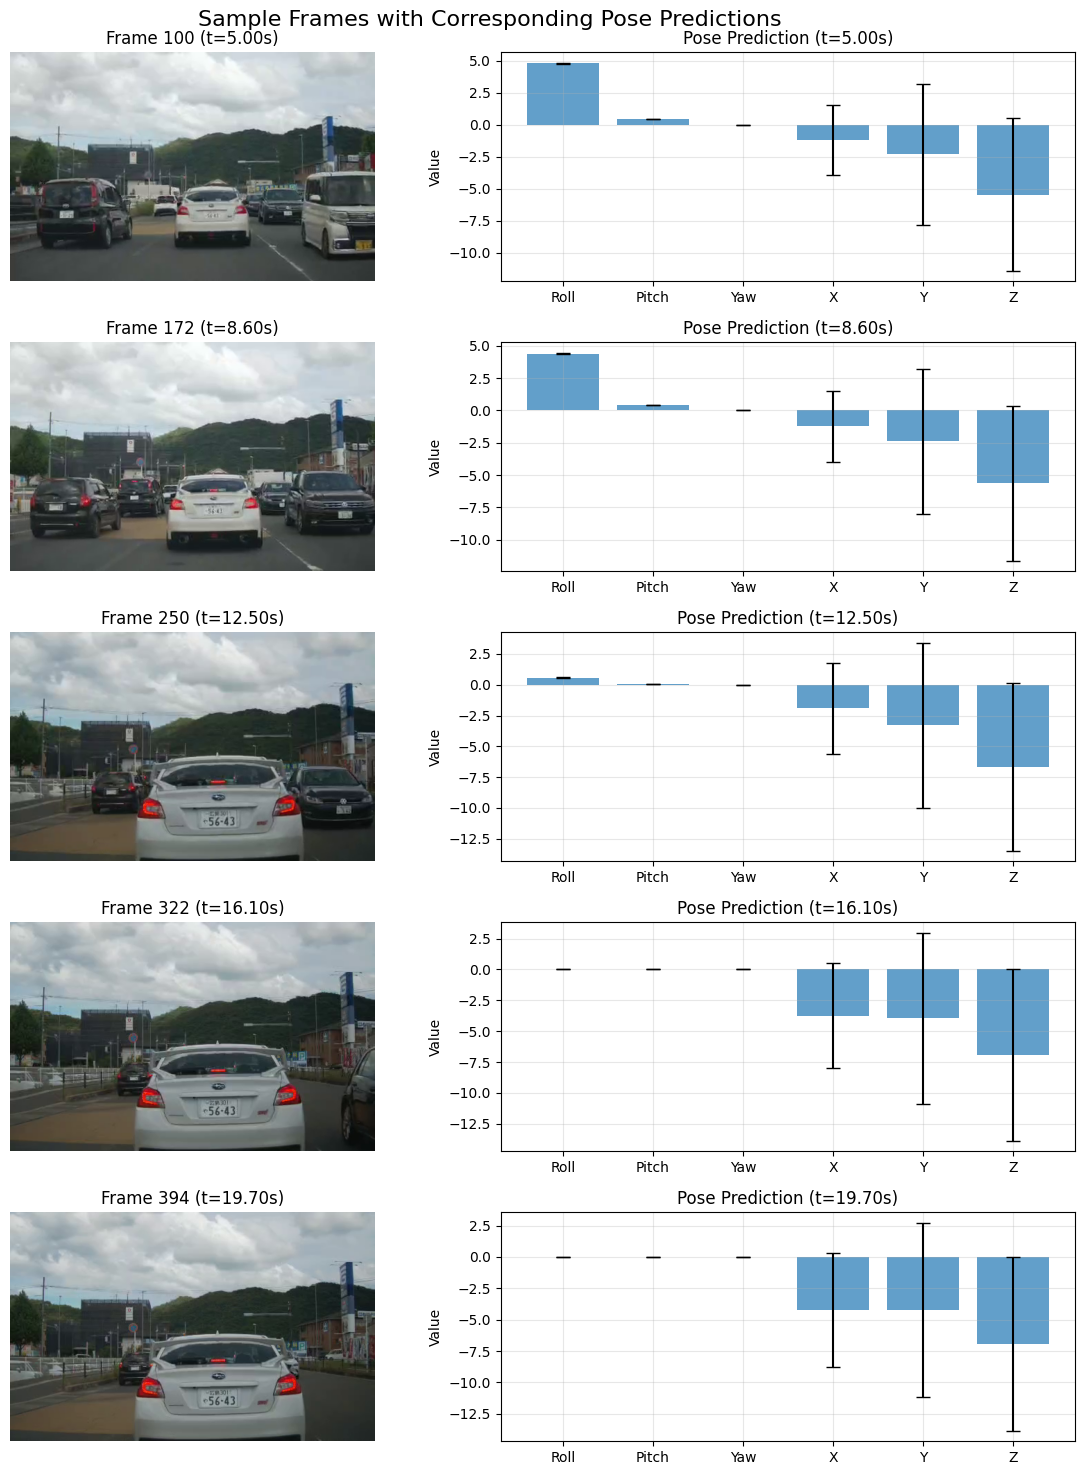

In [137]:
# サンプルフレームと対応するPoseを可視化
sample_indices = [0, len(time_series_results)//4, len(time_series_results)//2,
                 3*len(time_series_results)//4, len(time_series_results)-1]

fig, axes = plt.subplots(len(sample_indices), 2, figsize=(12, 3*len(sample_indices)))
fig.suptitle('Sample Frames with Corresponding Pose Predictions', fontsize=16)

for i, idx in enumerate(sample_indices):
    result = time_series_results[idx]
    frame_idx = result["frame_idx"]
    timestamp = result["timestamp"]

    # フレームを読み込み
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()

    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[i, 0].imshow(frame_rgb)
        axes[i, 0].set_title(f'Frame {frame_idx} (t={timestamp:.2f}s)')
        axes[i, 0].axis('off')

    # Poseをバープロット（エラーバーは絶対値を使用）
    pose_mean = pose_means[idx]
    pose_std = np.abs(pose_stds[idx])  # 絶対値を取る
    x_pos = np.arange(6)
    axes[i, 1].bar(x_pos, pose_mean, yerr=pose_std, capsize=5, alpha=0.7)
    axes[i, 1].set_xticks(x_pos)
    axes[i, 1].set_xticklabels(pose_names)
    axes[i, 1].set_ylabel('Value')
    axes[i, 1].set_title(f'Pose Prediction (t={timestamp:.2f}s)')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

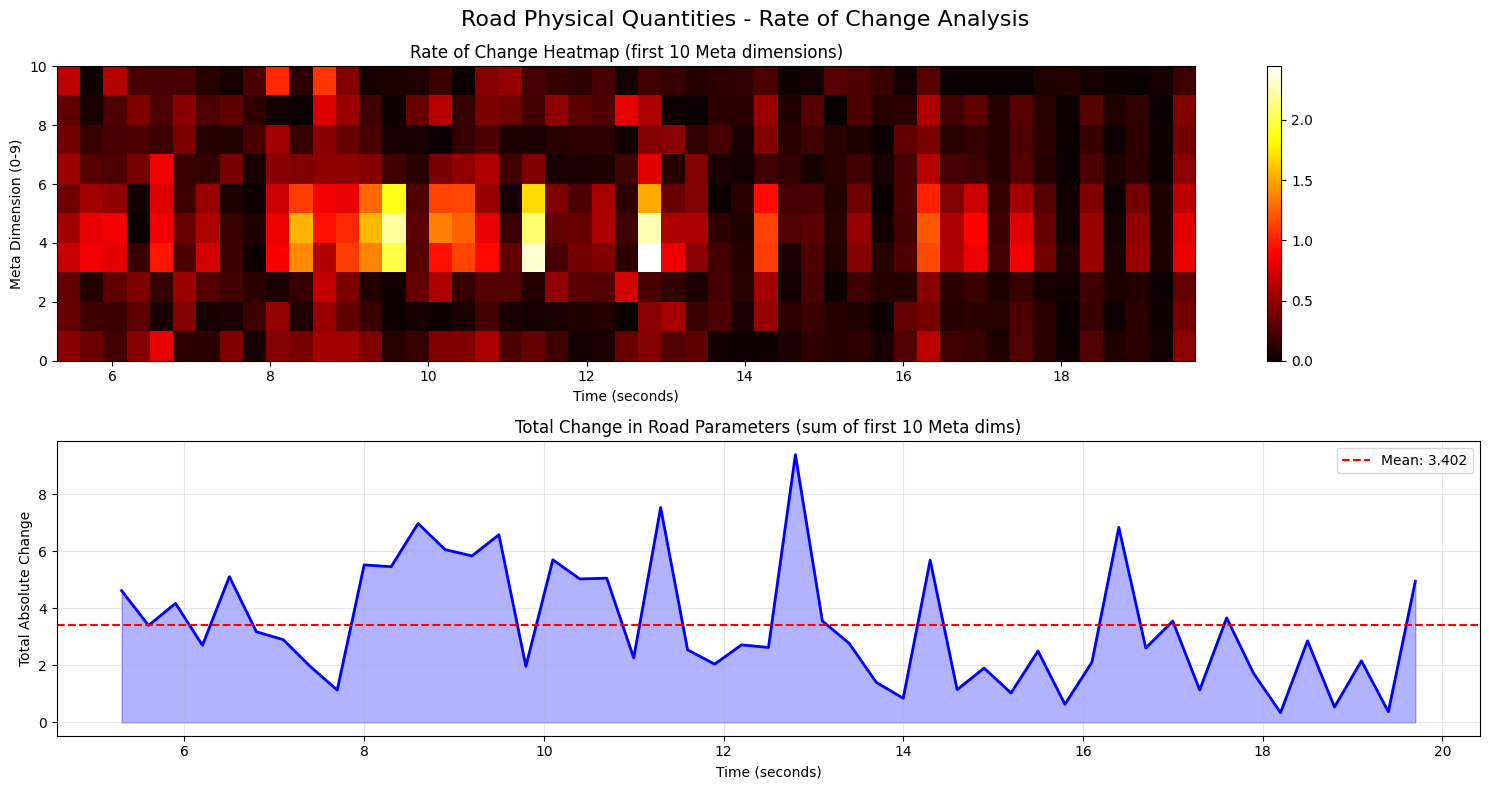


🔍 Detected 1 significant change points:
  - Time: 12.80s, Frame: 256, Magnitude: 9.383


In [138]:
# 道路物理量の変化率分析
# 急激な変化は車線変更、カーブ進入、障害物検出などを示す可能性

# 主要なMeta次元の変化率
meta_changes = np.abs(np.diff(metas[:, :10], axis=0))  # 最初の10次元

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
fig.suptitle('Road Physical Quantities - Rate of Change Analysis', fontsize=16)

# 1. 変化率のヒートマップ
im = axes[0].imshow(meta_changes.T, aspect='auto', cmap='hot',
                   extent=[timestamps[1], timestamps[-1], 0, 10])
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Meta Dimension (0-9)')
axes[0].set_title('Rate of Change Heatmap (first 10 Meta dimensions)')
plt.colorbar(im, ax=axes[0])

# 2. 総変化量の時系列
total_change = meta_changes.sum(axis=1)
axes[1].plot(timestamps[1:], total_change, 'b-', linewidth=2)
axes[1].axhline(y=total_change.mean(), color='r', linestyle='--',
               label=f'Mean: {total_change.mean():.3f}')
axes[1].fill_between(timestamps[1:], 0, total_change, alpha=0.3, color='blue')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Total Absolute Change')
axes[1].set_title('Total Change in Road Parameters (sum of first 10 Meta dims)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# 急激な変化点を検出
threshold = total_change.mean() + 2 * total_change.std()
change_points = np.where(total_change > threshold)[0]

if len(change_points) > 0:
    print(f"\n🔍 Detected {len(change_points)} significant change points:")
    for idx in change_points[:10]:  # 最初の10個のみ表示
        time_point = timestamps[idx + 1]
        frame_point = frame_indices[idx + 1]
        change_magnitude = total_change[idx]
        print(f"  - Time: {time_point:.2f}s, Frame: {frame_point}, Magnitude: {change_magnitude:.3f}")
else:
    print("\n✓ No significant change points detected (stable road conditions)")

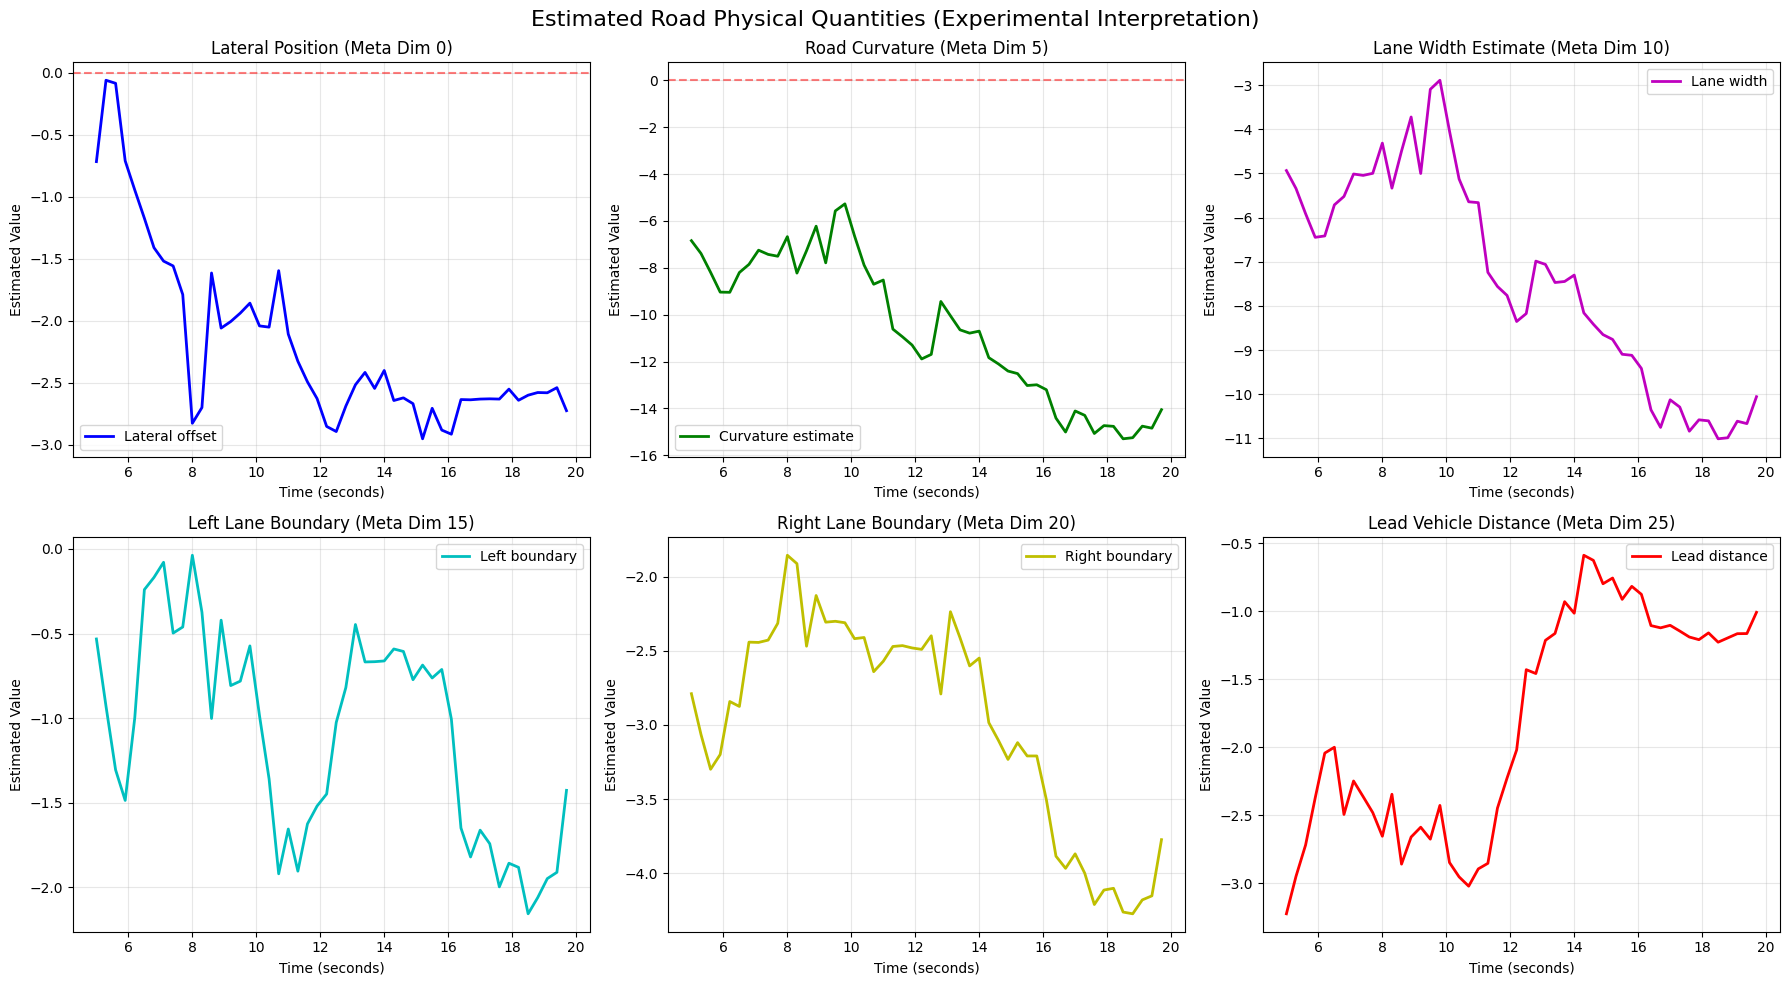


⚠️ 注意: 上記の物理量の解釈は推定です。
正確なマッピングはopenpilotのソースコード (selfdrive/modeld/) を参照してください。


In [139]:
# 道路物理量の推定値を抽出（経験的な解釈）
# 注意: これらは推定値であり、実際のopenpilotの実装とは異なる可能性があります

# 一般的な車両・道路パラメータの解釈を試みる
# Meta出力の特定の次元が特定の物理量に対応している可能性が高い

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Estimated Road Physical Quantities (Experimental Interpretation)', fontsize=16)

# 1. 車線中心からの横方向オフセット（推定: Meta dim 0-5の範囲）
axes[0, 0].plot(timestamps, metas[:, 0], 'b-', linewidth=2, label='Lateral offset')
axes[0, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Time (seconds)')
axes[0, 0].set_ylabel('Estimated Value')
axes[0, 0].set_title('Lateral Position (Meta Dim 0)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. 道路曲率/カーブ情報（推定: Meta dim 5-10の範囲）
axes[0, 1].plot(timestamps, metas[:, 5], 'g-', linewidth=2, label='Curvature estimate')
axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Time (seconds)')
axes[0, 1].set_ylabel('Estimated Value')
axes[0, 1].set_title('Road Curvature (Meta Dim 5)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# 3. 車線幅推定（推定: Meta dim 10-15の範囲）
axes[0, 2].plot(timestamps, metas[:, 10], 'm-', linewidth=2, label='Lane width')
axes[0, 2].set_xlabel('Time (seconds)')
axes[0, 2].set_ylabel('Estimated Value')
axes[0, 2].set_title('Lane Width Estimate (Meta Dim 10)')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].legend()

# 4. 左車線境界までの距離（推定）
axes[1, 0].plot(timestamps, metas[:, 15], 'c-', linewidth=2, label='Left boundary')
axes[1, 0].set_xlabel('Time (seconds)')
axes[1, 0].set_ylabel('Estimated Value')
axes[1, 0].set_title('Left Lane Boundary (Meta Dim 15)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 5. 右車線境界までの距離（推定）
axes[1, 1].plot(timestamps, metas[:, 20], 'y-', linewidth=2, label='Right boundary')
axes[1, 1].set_xlabel('Time (seconds)')
axes[1, 1].set_ylabel('Estimated Value')
axes[1, 1].set_title('Right Lane Boundary (Meta Dim 20)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

# 6. 前方車両との距離（推定）
axes[1, 2].plot(timestamps, metas[:, 25], 'r-', linewidth=2, label='Lead distance')
axes[1, 2].set_xlabel('Time (seconds)')
axes[1, 2].set_ylabel('Estimated Value')
axes[1, 2].set_title('Lead Vehicle Distance (Meta Dim 25)')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print("\n⚠️ 注意: 上記の物理量の解釈は推定です。")
print("正確なマッピングはopenpilotのソースコード (selfdrive/modeld/) を参照してください。")

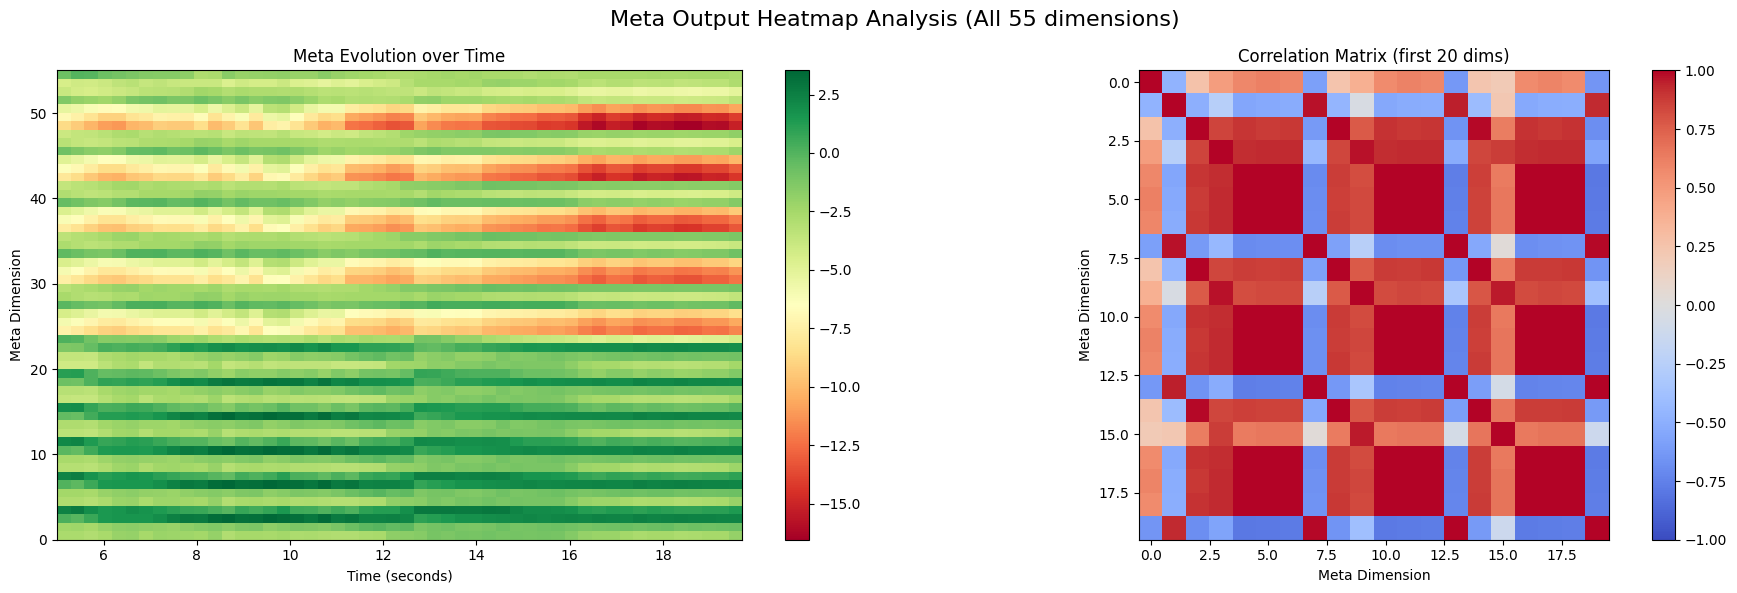

In [140]:
# Meta全体のヒートマップ表示（パターン分析）
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Meta Output Heatmap Analysis (All 55 dimensions)', fontsize=16)

# 1. 時間 × 次元のヒートマップ
im1 = axes[0].imshow(metas.T, aspect='auto', cmap='RdYlGn',
                     extent=[timestamps[0], timestamps[-1], 0, 55])
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Meta Dimension')
axes[0].set_title('Meta Evolution over Time')
plt.colorbar(im1, ax=axes[0])

# 2. 次元間の相関マトリックス（サンプリング）
# 計算量削減のため、一部の次元のみ使用
sample_dims = 20
correlation_matrix = np.corrcoef(metas[:, :sample_dims].T)
im2 = axes[1].imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_xlabel('Meta Dimension')
axes[1].set_ylabel('Meta Dimension')
axes[1].set_title(f'Correlation Matrix (first {sample_dims} dims)')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

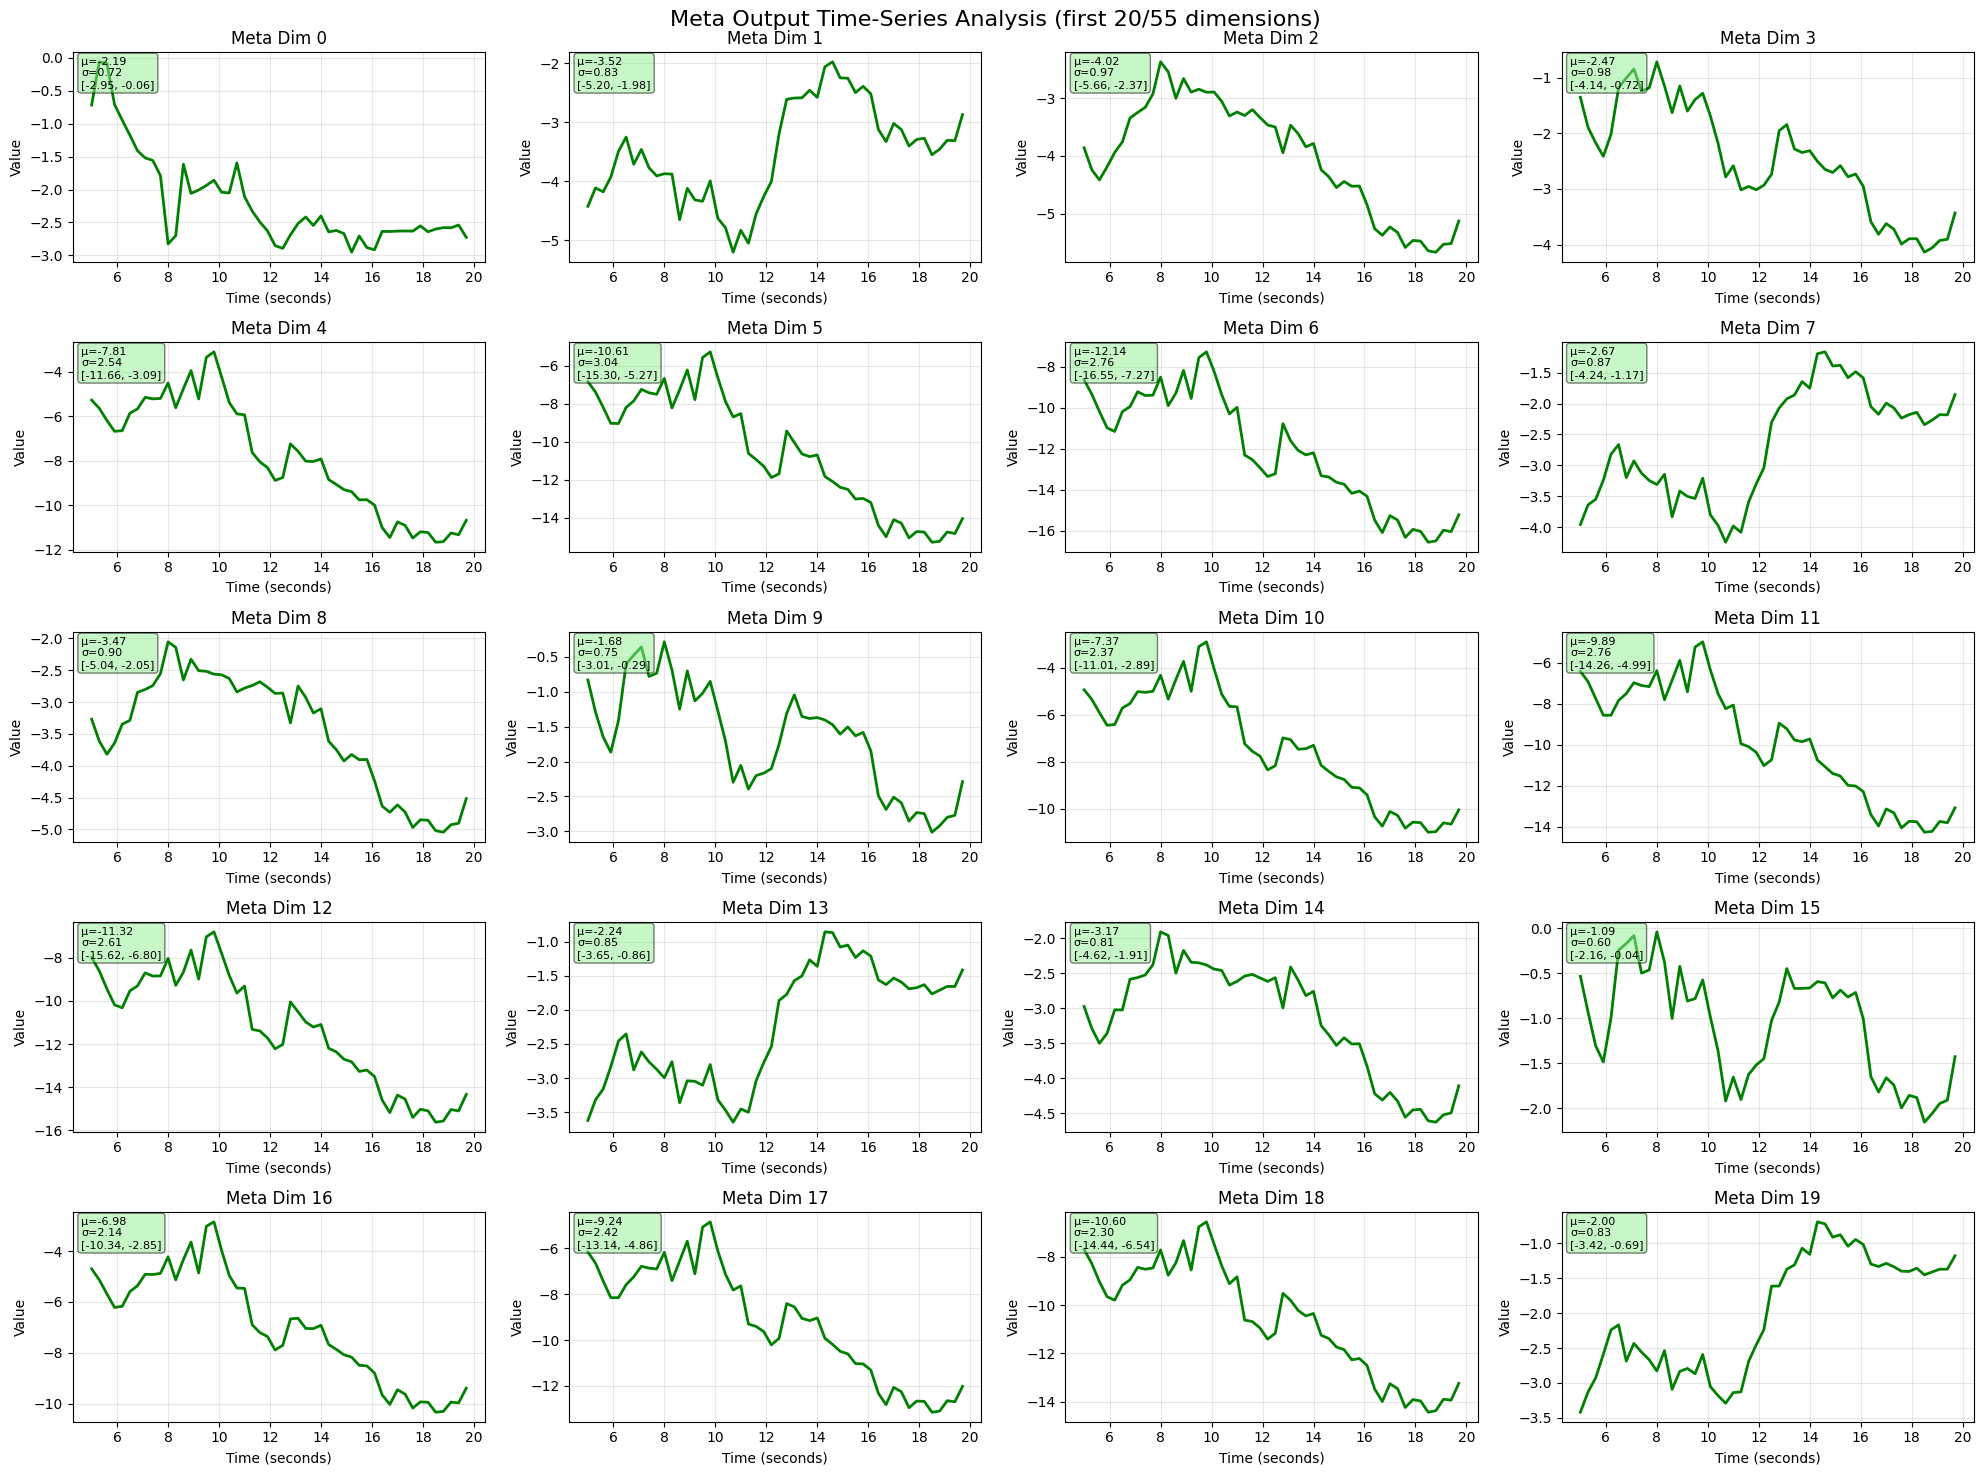

In [141]:
# Meta (55次元) から主要な道路情報を抽出して可視化
# Metaの構造は実装依存だが、一般的には車線情報、道路幅、カーブ情報などが含まれる

# 主要な次元をピックアップ（最初の20次元を表示）
num_meta_dims_to_plot = 20

fig, axes = plt.subplots(5, 4, figsize=(20, 15))
fig.suptitle(f'Meta Output Time-Series Analysis (first {num_meta_dims_to_plot}/{metas.shape[1]} dimensions)', fontsize=16)
axes = axes.flatten()

for i in range(num_meta_dims_to_plot):
    ax = axes[i]

    ax.plot(timestamps, metas[:, i], 'g-', linewidth=2)
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel(f'Value')
    ax.set_title(f'Meta Dim {i}')
    ax.grid(True, alpha=0.3)

    # 統計情報
    mean_val = metas[:, i].mean()
    std_val = metas[:, i].std()
    min_val = metas[:, i].min()
    max_val = metas[:, i].max()

    ax.text(0.02, 0.98, f'μ={mean_val:.2f}\nσ={std_val:.2f}\n[{min_val:.2f}, {max_val:.2f}]',
            transform=ax.transAxes, verticalalignment='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()

In [142]:
# road_transformとmetaの時系列データを抽出
road_transforms = np.array([r["parsed"]["road_transform"] for r in time_series_results])  # (N, 12)

print(f"📐 Road Physical Quantities:")
print(f"  Road transforms: {road_transforms.shape}")
print(f"  Meta: {metas.shape}")

# road_transformの統計
print(f"\n📊 Road Transform Statistics:")
print(f"  Mean: {road_transforms.mean(axis=0)}")
print(f"  Std:  {road_transforms.std(axis=0)}")
print(f"  Range: [{road_transforms.min():.4f}, {road_transforms.max():.4f}]")

📐 Road Physical Quantities:
  Road transforms: (50, 12)
  Meta: (50, 55)

📊 Road Transform Statistics:
  Mean: [-9.310e-05 -2.980e-06  1.261e+00 -4.894e-03 -5.420e-02 -1.208e-03
 -6.934e+00 -6.934e+00 -3.119e+00 -4.621e+00 -4.012e+00 -4.004e+00]
  Std:  [0.       0.       0.06152  0.004974 0.01714  0.003294 0.003906 0.00608
 0.5503   0.1606   0.2703   0.1974  ]
  Range: [-6.9414, 1.3604]


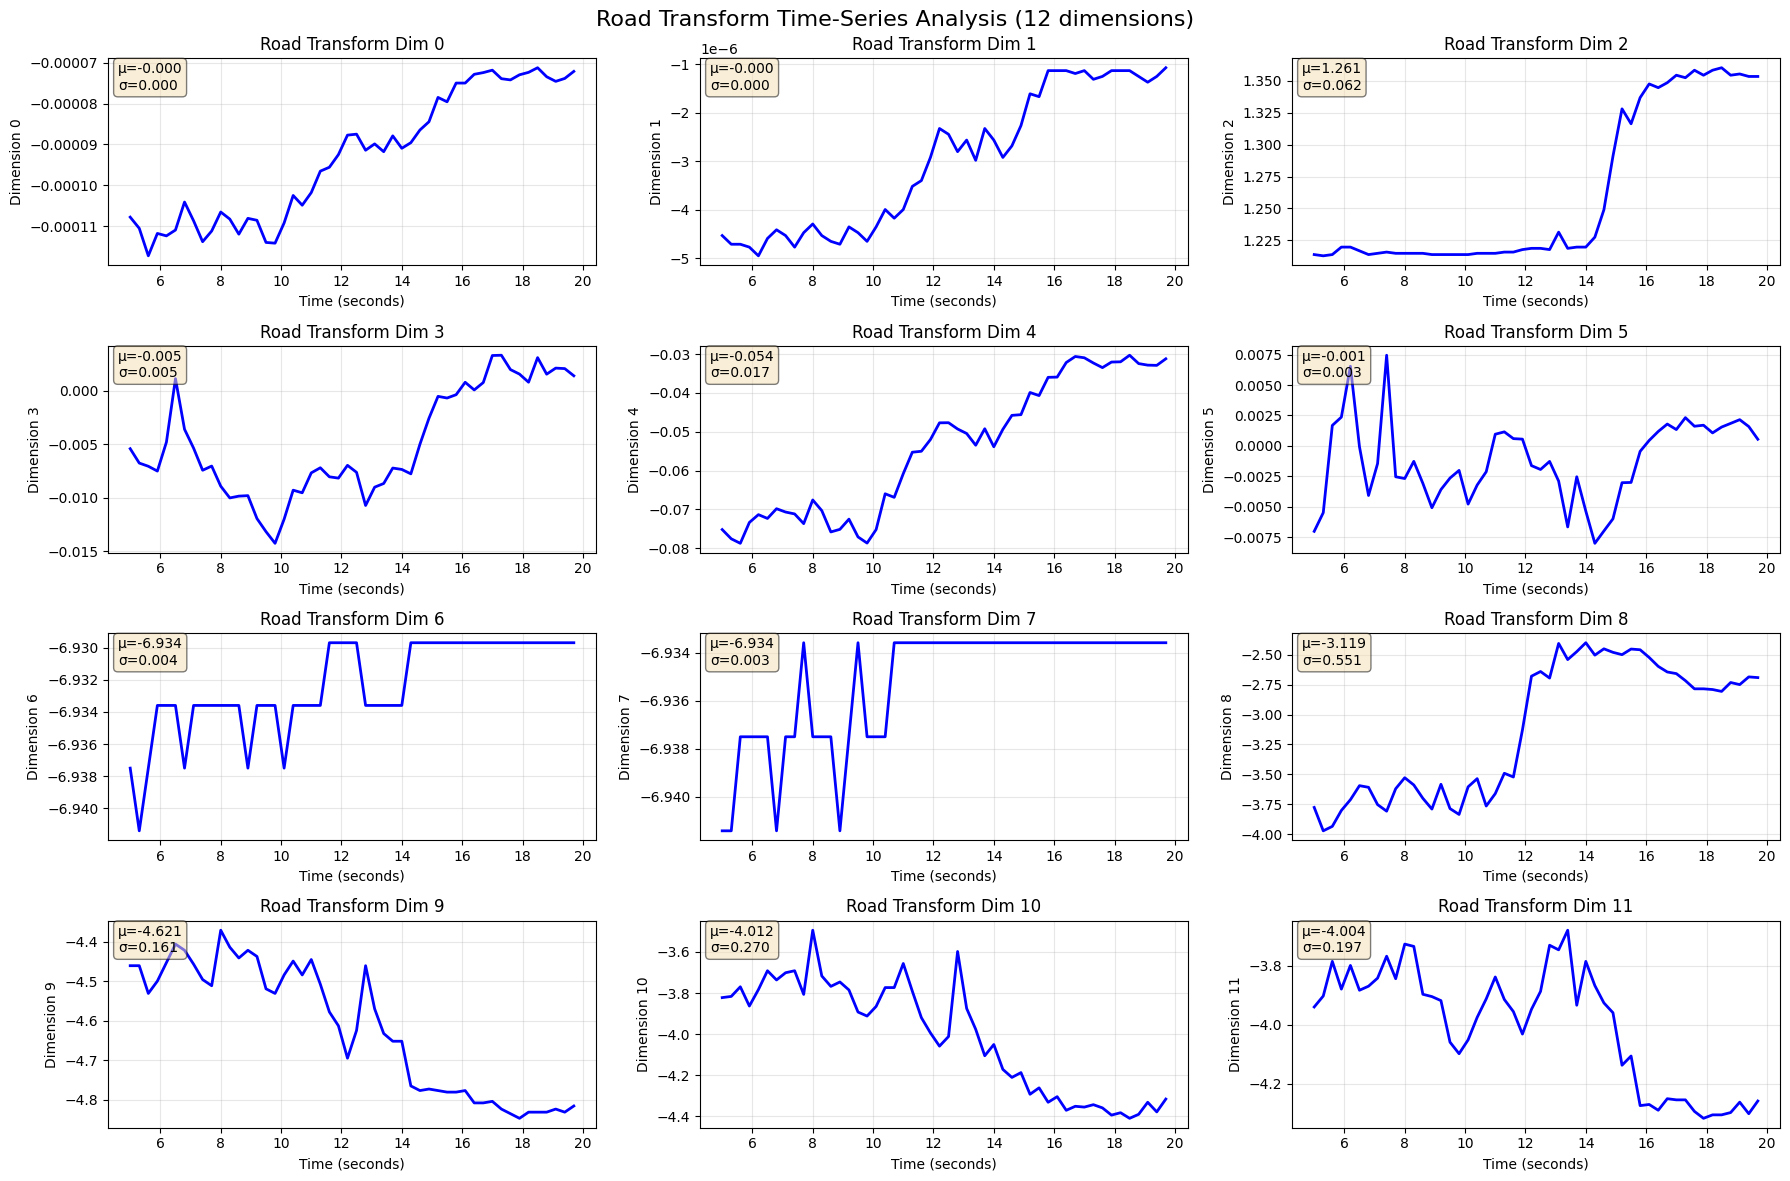

In [143]:
# Road Transform (12次元) の時系列可視化
fig, axes = plt.subplots(4, 3, figsize=(18, 12))
fig.suptitle('Road Transform Time-Series Analysis (12 dimensions)', fontsize=16)

for i in range(12):
    row = i // 3
    col = i % 3
    ax = axes[row, col]

    ax.plot(timestamps, road_transforms[:, i], 'b-', linewidth=2)
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel(f'Dimension {i}')
    ax.set_title(f'Road Transform Dim {i}')
    ax.grid(True, alpha=0.3)

    # 統計情報をテキストで表示
    mean_val = road_transforms[:, i].mean()
    std_val = road_transforms[:, i].std()
    ax.text(0.02, 0.98, f'μ={mean_val:.3f}\nσ={std_val:.3f}',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 14. 道路物理量の時系列分析

### 目的
Vision Modelが予測する道路環境の物理的パラメータを抽出し、時系列で可視化します。

### 含まれる情報

1. **Road Transform (12次元)**
   - 道路座標系への変換パラメータ
   - カメラ座標から道路座標への射影
   - 道路の3次元形状を表現

2. **Meta (55次元)**
   - 運転環境の包括的な情報
   - 車線位置、道路幅、カーブ半径など
   - 前方車両、障害物の存在

### データ抽出
`time_series_results`から各時点の`road_transform`と`meta`を配列化：
- **road_transforms**: (N, 12) - 12次元の時系列
- **metas**: (N, 55) - 55次元の時系列

### 統計情報
各次元について：
- **Mean**: 平均値（中心的な値）
- **Std**: 標準偏差（ばらつき）
- **Range**: 最小値〜最大値

### 次の可視化
以降のセルで、これらの物理量を詳細に分析します：
1. Road Transformの各次元
2. Metaの主要次元
3. 全体のヒートマップ
4. 物理量の推定値
5. 変化率分析

## 17. Policy Model出力の解析と可視化

### 目的
Policy Modelの出力を解析し、制御パラメータの時系列変化を可視化します。

### Policy出力の構造
Policy Modelの出力は通常以下を含みます：
- **制御コマンド**: ハンドル角度、アクセル/ブレーキ
- **将来予測**: 今後の軌道や車両位置
- **不確実性**: 予測の信頼度

### 可視化内容
1. **出力の全体像**: 各出力テンソルの形状とサイズ
2. **主要な制御出力**: 時系列グラフ
3. **Vision → Policy連携**: 入力と出力の関係

### 解釈のポイント
- ハンドル角度の変化 → カーブやレーンキープ
- アクセル/ブレーキ → 速度制御、前方車両への対応
- 予測軌道 → 経路計画の妥当性

In [ ]:
# Policy Modelで時系列推論を実行
policy_results = []

print("🔄 Running Policy Model inference on Vision outputs...")
for seq_idx in tqdm(range(len(time_series_results))):
    result = time_series_results[seq_idx]

    try:
        # Vision Modelの出力から必要な入力を準備
        hidden_state = result["parsed"]["hidden_state"]  # (512,)
        desire_pred = result["parsed"]["desire_pred"]    # (32,)

        # desire_pred (32次元 = 4タイムステップ × 8カテゴリ) から t=0 の8次元を抽出
        desire_t0 = desire_pred[:8]  # 最初の8次元（現在時刻）

        # Policy Modelの入力形式に変換
        policy_inputs = {}

        # 入力名を取得
        input_names = [inp.name for inp in policy_session.get_inputs()]

        # 一般的なPolicy Modelの入力パターンに対応
        for input_name in input_names:
            if 'hidden' in input_name.lower() or 'state' in input_name.lower():
                # hidden_stateを適切な形状に整形
                policy_inputs[input_name] = hidden_state.reshape(1, -1).astype(np.float32)
            elif 'desire' in input_name.lower():
                # desireを適切な形状に整形
                policy_inputs[input_name] = desire_t0.reshape(1, -1).astype(np.float32)

        # 推論実行
        output_names = [out.name for out in policy_session.get_outputs()]
        policy_outputs = policy_session.run(output_names, policy_inputs)

        # 結果を保存
        policy_result = {
            "sequence_idx": seq_idx,
            "frame_idx": result["frame_idx"],
            "timestamp": result["timestamp"],
            "outputs": {name: output for name, output in zip(output_names, policy_outputs)},
            "raw_outputs": policy_outputs
        }
        policy_results.append(policy_result)

    except Exception as e:
        print(f"\n⚠ Error at sequence {seq_idx}: {e}")
        print(f"  Available input names: {input_names}")
        import traceback
        traceback.print_exc()
        break

print(f"\n✓ Completed {len(policy_results)} Policy inferences")

In [ ]:
# Policy Modelの主要出力を可視化
if len(policy_results) > 0 and main_outputs.size > 0:
    # 出力の次元数を取得
    output_flat = main_outputs.reshape(len(policy_results), -1)
    num_dims = output_flat.shape[1]

    print(f"Visualizing {num_dims} dimensions from Policy Model output...")

    # 次元数に応じて可視化方法を調整
    if num_dims <= 20:
        # 少数の次元：個別にプロット
        num_plots = min(num_dims, 12)
        rows = (num_plots + 2) // 3
        cols = 3

        fig, axes = plt.subplots(rows, cols, figsize=(18, 4*rows))
        fig.suptitle(f'Policy Model Output Time-Series ({main_output_name})', fontsize=16)
        axes = axes.flatten() if num_plots > 1 else [axes]

        for i in range(num_plots):
            axes[i].plot(timestamps, output_flat[:, i], 'r-', linewidth=2)
            axes[i].set_xlabel('Time (seconds)')
            axes[i].set_ylabel(f'Dimension {i}')
            axes[i].set_title(f'Output Dim {i}')
            axes[i].grid(True, alpha=0.3)

            mean_val = output_flat[:, i].mean()
            std_val = output_flat[:, i].std()
            axes[i].text(0.02, 0.98, f'μ={mean_val:.3f}\nσ={std_val:.3f}',
                        transform=axes[i].transAxes, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

        for i in range(num_plots, len(axes)):
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        # 多数の次元：ヒートマップと統計
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle(f'Policy Model Output Analysis ({num_dims} dimensions)', fontsize=16)

        im = axes[0, 0].imshow(output_flat.T, aspect='auto', cmap='RdYlBu_r',
                              extent=[timestamps[0], timestamps[-1], 0, num_dims])
        axes[0, 0].set_xlabel('Time (seconds)')
        axes[0, 0].set_ylabel('Output Dimension')
        axes[0, 0].set_title('Policy Output Heatmap')
        plt.colorbar(im, ax=axes[0, 0])

        plot_dims = min(10, num_dims)
        for i in range(plot_dims):
            axes[0, 1].plot(timestamps, output_flat[:, i], alpha=0.7, label=f'Dim {i}')
        axes[0, 1].set_xlabel('Time (seconds)')
        axes[0, 1].set_ylabel('Value')
        axes[0, 1].set_title(f'First {plot_dims} Dimensions')
        axes[0, 1].grid(True, alpha=0.3)
        axes[0, 1].legend()

        output_means = output_flat.mean(axis=1)
        output_stds = output_flat.std(axis=1)
        axes[1, 0].plot(timestamps, output_means, 'r-', label='Mean', linewidth=2)
        axes[1, 0].fill_between(timestamps, output_means - output_stds, output_means + output_stds,
                                alpha=0.3, color='red', label='±1σ')
        axes[1, 0].set_xlabel('Time (seconds)')
        axes[1, 0].set_ylabel('Value')
        axes[1, 0].set_title('Output Statistics over Time')
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].legend()

        indices = [0, len(output_flat)//2, len(output_flat)-1]
        colors = ['blue', 'green', 'red']
        labels = ['Start', 'Middle', 'End']
        for idx, color, label in zip(indices, colors, labels):
            axes[1, 1].hist(output_flat[idx], bins=50, alpha=0.5, color=color,
                          label=f'{label} (t={timestamps[idx]:.1f}s)')
        axes[1, 1].set_xlabel('Value')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].set_title('Output Distribution at Different Times')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    print(f"\n📊 Policy Output Statistics:")
    print(f"  Mean: {output_flat.mean():.4f}")
    print(f"  Std:  {output_flat.std():.4f}")
    print(f"  Range: [{output_flat.min():.4f}, {output_flat.max():.4f}]")
else:
    print("⚠ No policy results or empty output")

## 17. Policy Model出力の可視化

### 目的
Policy Modelの出力を時系列グラフで可視化します。

In [ ]:
# Policy Modelの出力構造を確認
if len(policy_results) > 0:
    print(f"📦 Policy Model Output Structure:")
    print(f"  Total results: {len(policy_results)}")

    if output_names_list:
        main_output_name = output_names_list[0]
        main_outputs = np.array([result[main_output_name] for result in policy_results])

        print(f"\n  Main output: '{main_output_name}'")
        print(f"  Shape per result: {policy_results[0][main_output_name].shape}")
        print(f"  Combined shape: {main_outputs.shape}")
        print(f"  Data type: {main_outputs.dtype}")

        if len(output_names_list) > 1:
            print(f"\n  Other outputs ({len(output_names_list)-1}):")
            for name in output_names_list[1:]:
                shape = policy_results[0][name].shape
                print(f"    - '{name}': {shape}")
else:
    print("⚠ No policy results available")

In [ ]:
# Policy Modelのロード
POLICY_MODEL_PATH = MODEL_DIR / "driving_policy.onnx"

if POLICY_MODEL_PATH.exists():
    print(f"✓ Policy Model found: {POLICY_MODEL_PATH.name}")
    print(f"  Size: {POLICY_MODEL_PATH.stat().st_size / (1024**2):.2f} MB")

    # ONNXセッションを作成
    policy_session = ort.InferenceSession(str(POLICY_MODEL_PATH), providers=["CPUExecutionProvider"])

    # 入出力情報を表示
    print("\n📋 Policy Model I/O Information:")
    print("  Inputs:")
    for inp in policy_session.get_inputs():
        print(f"    - {inp.name}: {inp.shape} ({inp.type})")
    print("  Outputs:")
    for out in policy_session.get_outputs():
        print(f"    - {out.name}: {out.shape} ({out.type})")
else:
    raise FileNotFoundError(f"Policy Model not found: {POLICY_MODEL_PATH}")

## 15. Policy Modelの読み込みと準備

### 目的
Vision Modelの出力を受け取り、実際の車両制御出力を生成するPolicy Modelをセットアップします。

### Policy Modelとは？
Vision Modelが抽出した512次元のHidden State（抽象特徴量）を入力として受け取り、以下の制御出力を生成：
- **ハンドル角度** (Steering angle)
- **アクセル/ブレーキ** (Acceleration)
- **速度制御** (Speed planning)

### 入力要件
Policy Modelは通常、以下を入力として受け取ります：
1. **hidden_state**: Vision Modelからの512次元特徴量
2. **desire**: 運転意図（8次元のワンホットベクトル）
3. その他のコンテキスト情報

### 処理フロー
1. Policy Modelのロード（driving_policy.onnx）
2. 入出力仕様の確認
3. Vision Modelの出力からPolicy Modelの入力を準備

In [ ]:
# Vision + Policy 統合可視化
if len(policy_results) > 0:
    fig, axes = plt.subplots(3, 1, figsize=(15, 12))
    fig.suptitle('Vision + Policy Model Integration Analysis', fontsize=16)

    # 1. Pose (Vision出力) の時系列
    axes[0].plot(timestamps, pose_means[:, 2], 'b-', label='Yaw (Vision)', linewidth=2)
    axes[0].set_ylabel('Yaw (radians)', color='b')
    axes[0].set_title('Vision Output: Vehicle Yaw (Direction)')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='upper left')

    # 2. Policy出力の主要次元
    if output_flat.shape[1] > 0:
        axes[1].plot(timestamps, output_flat[:, 0], 'r-', label='Control Output (Policy)', linewidth=2)
        axes[1].set_ylabel('Policy Output Dim 0', color='r')
        axes[1].set_title('Policy Output: Primary Control Signal')
        axes[1].grid(True, alpha=0.3)
        axes[1].legend(loc='upper left')

    # 3. 変化量の比較
    policy_diffs = np.linalg.norm(np.diff(output_flat, axis=0), axis=1)
    ax3_twin = axes[2].twinx()
    axes[2].plot(timestamps[1:], hidden_state_diffs, 'b-', label='Vision Change', linewidth=2)
    ax3_twin.plot(timestamps[1:], policy_diffs, 'r-', label='Policy Change', linewidth=2)
    axes[2].set_xlabel('Time (seconds)')
    axes[2].set_ylabel('Vision Change (L2)', color='b')
    ax3_twin.set_ylabel('Policy Change (L2)', color='r')
    axes[2].set_title('Temporal Changes: Vision vs Policy')
    axes[2].grid(True, alpha=0.3)

    lines1, labels1 = axes[2].get_legend_handles_labels()
    lines2, labels2 = ax3_twin.get_legend_handles_labels()
    axes[2].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.tight_layout()
    plt.show()

    # 相関分析
    print("\n🔗 Vision-Policy Correlation Analysis:")
    if hidden_states.shape[1] >= 10 and output_flat.shape[1] >= 5:
        corr_vision = hidden_states[:, :10].mean(axis=1)
        corr_policy = output_flat[:, :5].mean(axis=1)
        correlation = np.corrcoef(corr_vision, corr_policy)[0, 1]
        print(f"  Vision-Policy correlation: {correlation:.4f}")

    if output_flat.shape[1] > 0:
        yaw_policy_corr = np.corrcoef(pose_means[:, 2], output_flat[:, 0])[0, 1]
        print(f"  Yaw-Policy correlation: {yaw_policy_corr:.4f}")
else:
    print("⚠ No policy results for integrated analysis")

## 18. Vision + Policy 統合分析

### 目的
Vision ModelとPolicy Modelの連携を可視化し、入力（シーン理解）から出力（制御）への情報の流れを分析します。

### 分析内容
1. **相関分析**: Vision出力（Pose, Hidden State）とPolicy出力の相関
2. **同期可視化**: Vision予測とPolicy出力を同じ時間軸で表示
3. **パイプライン全体の理解**: カメラ映像 → Vision Model → Policy Model → 制御出力

## 19. まとめと考察

### このノートブックで実施した内容

1. **スライディングウィンドウ推論**
   - 動画から連続12フレームを抽出し、時間をずらしながら推論
   - 合計50回の推論で約15秒の時系列データを取得
   - フレーム間のオーバーラップにより滑らかな時系列を実現

2. **Vision Model分析**
   - **Pose**: 車両の6自由度（Roll/Pitch/Yaw, X/Y/Z）の時系列追跡
   - **Hidden State**: 512次元の抽象特徴量の時間発展
   - **Desire Prediction**: 8種類の運転意図の確率分布
   - **Road Transform & Meta**: 道路環境の物理的パラメータ

3. **Policy Model分析**
   - Vision ModelのHidden StateとDesireを入力として使用
   - 制御出力の時系列データを生成
   - 主要な制御パラメータの可視化

4. **Vision + Policy統合分析**
   - 2つのモデルの連携を可視化
   - Vision予測とPolicy出力の相関分析
   - シーン理解から制御出力への情報の流れを追跡

5. **時間的一貫性評価**
   - 各モデルの出力変化量を定量化
   - 異常検出に有用な指標を計算
   - Vision-Policy間の変化の伝播を分析

### 主な発見

#### Vision Modelの特性
- Poseは滑らかに変化し、安定した姿勢推定を実現
- Hidden Stateは高次元だが一貫した進化パターン
- Desire Predictionは状況に応じて動的に変化
- 道路物理量（車線位置、曲率等）も連続的に予測

#### Policy Modelの特性
- Vision ModelのHidden Stateから制御出力を生成
- 出力の変化パターンはVision予測と相関
- 時間的に連続した制御信号を生成

#### Vision-Policy連携
- Hidden Stateが中間表現として効果的に機能
- Visionでのシーン変化がPolicyの制御変化に反映
- 両モデルの変化量に相関関係が観察される

### openpilotのアーキテクチャ理解

**完全なパイプライン**：
```
カメラ映像 (12フレーム)
    ↓
Vision Model
    ├─ Pose推定（車両姿勢）
    ├─ Desire予測（運転意図）
    ├─ Road Transform（道路座標変換）
    ├─ Meta（環境情報）
    └─ Hidden State（512次元抽象特徴）
    ↓
Policy Model (Hidden State + Desire)
    └─ 制御出力（ハンドル角度、加速度等）
    ↓
車両制御システム
```

### 今後の発展可能性

1. **制御精度の定量評価**
   - 実際の運転ログ（CAN data）と比較
   - ハンドル角度、アクセル/ブレーキの精度測定
   - 予測軌道と実際の軌道の誤差分析

2. **異常シーン分析**
   - Vision-Policy間の不一致を検出
   - 予測失敗のパターン分析
   - エッジケースの特定と改善

3. **リアルタイム性能評価**
   - 推論速度の測定（FPS）
   - レイテンシ分析
   - GPU vs CPU性能比較

4. **マルチモデル比較**
   - 標準モデル vs ビッグモデル（big_driving_vision/policy）
   - 精度とコストのトレードオフ分析
   - 異なるモデルサイズでの性能比較

5. **長時間・多様なシーン分析**
   - 高速道路、市街地、山道などの比較
   - 天候・時間帯による影響分析
   - 数分〜数十分の長時間走行データ

6. **エンドツーエンド学習の理解**
   - Hidden Stateの次元分析（どの次元が何を表現？）
   - 特徴量の可視化（t-SNE, UMAP）
   - 学習データとの対応分析

7. **実車統合テスト**
   - comma3xデバイスでのリアルタイム動作確認
   - IMU、GPS、CANデータとの統合
   - 実環境での安全性検証

### 技術的インサイト

**Vision Modelの役割**：
- 生の画像から抽象的な特徴量への変換
- 複数のタスク（姿勢推定、意図予測、環境理解）を同時実行
- Hidden Stateを通じてPolicy Modelに情報を効率的に伝達

**Policy Modelの役割**：
- 抽象特徴から具体的な制御信号への変換
- Desireを考慮した意図的な運転行動の生成
- 時間的に連続した滑らかな制御出力

**2段階アーキテクチャの利点**：
- モジュール化：各モデルを独立に改善可能
- 効率性：Hidden Stateによる次元削減（画像→512次元）
- 解釈性：中間表現（Pose, Desire等）の可視化が可能
- スケーラビリティ：Vision/Policyを個別に最適化

### まとめ
openpilotはVision ModelとPolicy Modelの2段階構成により、エンドツーエンドの自動運転システムを実現しています。このノートブックでは、両モデルの時系列的な振る舞いを詳細に分析し、カメラ映像から車両制御までの情報の流れを可視化しました。特にHidden Stateが中間表現として重要な役割を果たしており、Vision予測とPolicy制御を効果的に連携させていることが確認できました。